# Модель поведенческого скоринга для выявления риска просрочек по платежам

## Цели и задачи
### Цель:
Разработать модель, которая будет предсказывать наличие и вероятность риска просрочки платежа по кредиту в 90 дней на основании данных за выбранный месяц. 

### Постановка задачи в терминах машинного обучения
- Тип задачи машинного обучения: бинарная классификация на основе данных с временной структурой.
- Целевая переменная - идентификатор класса (0/1), факт наличия просрочки на 90 дней по платежам в горизонте прогнозирования 12 месяцев.
- Модели машинного обучения - логистическая регрессия, случайный лес.
- Методы корректировки дисбаланса классов - оверсэмплинг, андерсэмплинг, модификация лосса (взвешивание).
- Необходимо использовать кросс-валидацию данных на основе временных рядов для оценки качества моделей. Количество фолдов - 3.
- Основные метрики - Approval Rate, Default Rate, Missed Defaults Rate. Вспомогательные метрики - Accuracy, ROC-AUC.     
- Требования к значениям метрик:
    - Approval rate не менее 65%.
    - Default rate не более 2%.
    - Missed defaults rate не более 4%.
- Для подбора оптимального набора гиперпараметров следует использовать байесовскую оптимизацию.
- Вероятности принадлежности к классам, возвращаемые моделью, должны быть откалиброваны.
- Необходимо обеспечить воспроизводимость результатов при помощи указания фиксированного значения `random_state`.

### Задачи:
1. Загрузка таблиц датасета.
2. Объединение таблиц в единый датасет, расчет таргета.
4. Исследовательский анализ данных.
5. Предобработка данных для машинного обучения, добавление новых признаков.
6. Обучение базовых моделей логистической регрессии и случайного леса с параметрами по умолчанию.
7. Обучение базовых моделей логистической регрессии и случайного леса с параметрами по умолчанию и с использованием методов балансировки классов.
8. Получение и сравнение оценок базовых моделей на кросс-валидации.
9. Подбор гиперпараметров для модели случайного леса при помощи библиотеки Optuna с использование кросс-валидации.
7. Обучение модели случайного леса с лучшими гиперпараметрами и стратегией балансировки классов.
8. Калибровка обученной модели, построение графиков калибровки.
9. Исследование стабильности метрик на калибровочной и тестовой выборках.
10. Оценка важности признаков.
11. Формулировка выводов и рекомендаций по дальнейшему усовершенствованию модели.


### Описание данных
В моделях поведенческого скоринга учитываются разные типы признаков:

- Социально-демографические факторы.
- Финансовое поведение клиента, включая траты по MCC-кодам.
- Источники поступлений денежных средств.
- Регулярность поступлений денежных средств.
- Динамика кредитного рейтинга.
- Наличие ипотечных и семейных обязательств.
- Макроэкономические факторы.

**Таблица 1. Данные о просрочке платежа (loan_payment_credit)**

Содержит столбцы:

- `ID` — идентификатор клиента.
- `дата_начала_периода` — дата начала периода просрочки.
- `просрочка_дней` — длительность просрочки в днях.

**Таблица 2. Месячные транзакции клиента (transactions)**

Таблица содержит информацию о тратах клиента по MCC-кодам.

- `ID` — идентификатор клиента.
- `date` — календарная дата по месяцам.
- `MCC_5300` — помесячные траты клиента по коду 5300.
- `MCC_5814` — помесячные траты клиента по коду 5814.
- `MCC_5812` — помесячные траты клиента по коду 5812.
- `MCC_5411` — помесячные траты клиента по коду 5411.
- `MCC_3990` — помесячные траты клиента по коду 3990.
- `MCC_5722` — помесячные траты клиента по коду 5722.
- `MCC_4900` — помесячные траты клиента по коду 4900.
- `MCC_другое` — помесячные траты клиента по остальным кодам.

Расшифровка кодов:

|**MCC-код**|**Категория**|**Расшифровка и примеры**|
|---|---|---|
|5300|Оптовики|Маркетплейсы: Ozon, Lamoda, Wildberries и другие.|
|5814|Фастфуд|Рестораны быстрого питания: «Вкусно — и точка», «Бургер Кинг» и другие.|
|5812|Места общественного питания, рестораны|Столовые и кафе: «Якитория», «Хлеб Насущный» и другие.|
|5411|Бакалейные магазины, супермаркеты|Большинство продуктовых магазинов: «Пятёрочка», «Магнит» и другие.|
|3990|Экосистема Яндекса|Яндекс Афиша, Яндекс Такси, Яндекс Книги и другие сервисы.|
|5722|Бытовое оборудование|Магазины, продающие технику для дома: «М.Видео», «Ситилинк» и другие.|
|4900|Жилищно-коммунальные услуги|Точки, оказывающие услуги по передаче или распределению электроэнергии, газа, установке и обслуживанию систем водоснабжения, сбору и утилизации отходов.|
|MCC_другое|Остальные категории||

**Таблица 3. Описание клиента на момент регистрации в банке (client_description)**

Содержит столбцы:

- `ID` — идентификатор клиента.
- `возраст` — возраст клиента.
- `семейное_положение` — семейное положение клиента. Три состояния: `разведённые`, `есть семья`, `нет семьи`.
- `наличие_иждивенцев` — есть ли у клиента лица на финансовом попечении: `1` — да, `0` — нет.
- `дата_регистрации` — календарная дата начала взаимоотношений банка и клиента.

**Таблица 4. Описание кредита (credit_description)**

Содержит столбцы:

- `ID` — идентификатор клиента.
- `доход` — месячный доход клиента на момент взятия кредита в рублях.
- `сумма_кредита` — сумма кредита, выданного клиенту, в рублях.

**Таблица 5. Данные о наличии ипотеки (mortgage_presence)**

Содержит столбцы:

- `ID` — идентификатор клиента.
- `дата_открытия` — календарная дата, когда клиент оформил ипотеку.
- `наличие_ипотеки` — есть ли у клиента ипотека: `1` — да, `0` — нет.

**Таблица 6. Данные о кредитном рейтинге клиента (credit_rating)**

Содержит столбцы:

- `ID` — идентификатор клиента.
- `date` — календарная дата получения рейтинга из внешнего источника.
- `кредитный_рейтинг` — значение рейтинга клиента на конкретную дату.

**Таблица 7. Данные о макроэкономических показателях России (macro_data)**

Содержит столбцы:

- `date` — месяц и год, на которые актуальны указанные показатели.
- `учетная_ставка` — учётная ставка в процентах.
- `уровень_безработицы` — уровень безработицы в процентах.
- `инфляция` — инфляция в процентах.

**Таблица 8. Данные о дате проведения поведенческого скоринга (cohort_grid)**

Содержит столбцы:

- `ID` — идентификатор клиента.
- `score_date` — дата скоринга.

## 1. Подготовка среды и загрузка данных

### 1.1. Установка библиотек

In [1]:
%pip install scikit-learn
%pip install -q --upgrade seaborn
%pip install -q --upgrade jinja2
%pip install -q phik
%pip install -q optuna
%pip install -q joblib
%pip install -q mlxtend
%pip install -q imblearn

# Сохраним версии библиотек в requirements.txt
%pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


### 1.2. Импорт необходимых библиотек

In [2]:
import os
from urllib.request import urlopen

# Библиотеки для вычислений и работы с датасетами
import pandas as pd
import numpy as np
import phik
from scipy.stats import chi2_contingency

# Библиотеки машинного обучения
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import f1_score, accuracy_score, precision_score, roc_auc_score, \
    recall_score, brier_score_loss, precision_recall_curve, confusion_matrix
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

from mlxtend.evaluate.time_series import (
    GroupTimeSeriesSplit,
    plot_splits,
    print_cv_info,
    print_split_info,
) 

# Подбор гиперпараметров
import optuna

# Библиотеки для построения графиков
import seaborn as sns
import matplotlib.pyplot as plt

# Сериализация пайплайна
import joblib

# Для форматирования в HTML
from IPython.display import display, HTML, Markdown

c:\Users\TEXNH MAKPH\Projects\Yandex DS\ds-yandex\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1.3. Загрузка данных

In [3]:
# Константы и общие настройки
RANDOM_SEED = 42

# Горизонт планирования в месяцах
PLANNING_HORIZON_MONTHS = 12

# Учитываемая просрочка в днях
DEFAULT_DURATION_DAYS = 90

pd.options.display.float_format = '{:.4f}'.format

BASE_URL = "https://code.s3.yandex.net/"

def load_dataset(file_name, **kwargs):
    try:
        if os.path.exists(file_name):
            return pd.read_csv(file_name, **kwargs)
        else:
            return pd.read_csv(BASE_URL + file_name, **kwargs)
    except:
        print("Ошибка загрузки датасета")
        raise

datasets = {}
datasets["loan_payment_credit"] = load_dataset("datasets/ds_15_loan_payment_credit.csv",
                                               parse_dates=['дата_начала_периода'])
datasets["transactions"] = load_dataset("datasets/ds_15_transactions.csv",
                                               parse_dates=['date'])
datasets["client_description"] = load_dataset("datasets/ds_15_client_description.csv",
                                               parse_dates=['дата_регистрации'])
datasets["credit_description"] = load_dataset("datasets/ds_15_credit_description.csv")
datasets["mortgage_presence"] = load_dataset("datasets/ds_15_mortgage_presence.csv",
                                               parse_dates=['дата_открытия'])
datasets["credit_rating"] = load_dataset("datasets/ds_15_credit_rating.csv",
                                               parse_dates=['date'])
datasets["macro_data"] = load_dataset("datasets/ds_15_macro_data.csv",
                                               parse_dates=['date'])
datasets["cohort_grid"] = load_dataset("datasets/ds_15_cohort_grid.csv",
                                               parse_dates=['score_date'])

for key, value in datasets.items():
    display(HTML("<h2>Таблица " + key + "</h2>"))
    display(value.info())
    display(value.head())

last_month = max(datasets['cohort_grid']['score_date'])
display(HTML(f'''<h2>Диапазон дат: </h2> с {min(datasets['cohort_grid']['score_date']):%Y-%m-%d} по
             {last_month:%Y-%m-%d}'''))

<class 'pandas.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   5500 non-null   str           
 1   дата_начала_периода  5500 non-null   datetime64[us]
 2   просрочка_дней       5500 non-null   int64         
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 129.0 KB


None

,ID,дата_начала_периода,просрочка_дней
0,IDF55109846,2014-12-01,120
1,IDF54995533,2015-06-01,121
2,IDF54964538,2018-03-01,87
3,IDF55079777,2019-09-01,109
4,IDF55093915,2017-02-01,84


<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   ID          577494 non-null  str           
 1   date        577494 non-null  datetime64[us]
 2   MCC_5300    577494 non-null  float64       
 3   MCC_5814    577494 non-null  float64       
 4   MCC_5812    577494 non-null  float64       
 5   MCC_5411    577494 non-null  float64       
 6   MCC_3990    577494 non-null  float64       
 7   MCC_5722    577494 non-null  float64       
 8   MCC_4900    577494 non-null  float64       
 9   MCC_другое  577494 non-null  float64       
dtypes: datetime64[us](1), float64(8), str(1)
memory usage: 44.1 MB


None

,ID,date,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое
0,IDF55109846,2013-05-01,3267.5900,1282.1100,1457.9600,5711.1000,647.4300,2374.7800,4059.8600,3657.3500
1,IDF55109846,2013-06-01,3196.5800,2443.3700,1334.2000,5824.6500,1067.5500,2187.1100,4592.2600,3322.6100
2,IDF55109846,2013-07-01,3550.5400,4277.7200,1463.7500,5209.5100,1167.9500,2076.5400,3605.2500,3467.0600
3,IDF55109846,2013-08-01,3385.9800,4530.6300,1261.4000,5765.9600,986.9900,2231.7700,2209.3900,3354.4400
4,IDF55109846,2013-09-01,3214.8400,4146.6500,1405.1500,5632.1100,640.7600,2156.6700,1519.4600,4352.9000


<class 'pandas.DataFrame'>
RangeIndex: 13500 entries, 0 to 13499
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ID                  13500 non-null  str           
 1   возраст             13500 non-null  int64         
 2   семейное_положение  13500 non-null  str           
 3   наличие_иждивенцев  13500 non-null  int64         
 4   дата_регистрации    13500 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(2), str(2)
memory usage: 527.5 KB


None

,ID,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации
0,IDF55109846,41,разведённые,1,2013-05-01
1,IDF54900291,45,разведённые,1,2017-12-01
2,IDF54995533,34,разведённые,1,2013-11-01
3,IDF55065581,40,нет семьи,1,2018-08-01
4,IDF55057353,66,разведённые,0,2018-05-01


<class 'pandas.DataFrame'>
RangeIndex: 13500 entries, 0 to 13499
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   ID             13500 non-null  str  
 1   доход          13500 non-null  int64
 2   сумма_кредита  13500 non-null  int64
dtypes: int64(2), str(1)
memory usage: 316.5 KB


None

,ID,доход,сумма_кредита
0,IDF55109846,27035,1960785
1,IDF54900291,64502,3375810
2,IDF54995533,90477,401700
3,IDF55065581,133475,1952655
4,IDF55057353,51324,1107870


<class 'pandas.DataFrame'>
RangeIndex: 6609 entries, 0 to 6608
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ID               6609 non-null   str           
 1   дата_открытия    6609 non-null   datetime64[us]
 2   наличие_ипотеки  6609 non-null   int64         
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 155.0 KB


None

,ID,дата_открытия,наличие_ипотеки
0,IDF54896351,2013-03-01,1
1,IDF54896367,2018-01-01,1
2,IDF54896414,2018-02-01,1
3,IDF54896494,2019-02-01,1
4,IDF54896615,2018-12-01,1


<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 3 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ID                 577494 non-null  str           
 1   date               577494 non-null  datetime64[us]
 2   кредитный_рейтинг  577494 non-null  int64         
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 13.2 MB


None

,ID,date,кредитный_рейтинг
0,IDF55109846,2013-05-01,692
1,IDF55109846,2013-06-01,688
2,IDF55109846,2013-07-01,666
3,IDF55109846,2013-08-01,692
4,IDF55109846,2013-09-01,688


<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 84 non-null     datetime64[us]
 1   учетная_ставка       84 non-null     float64       
 2   уровень_безработицы  84 non-null     float64       
 3   инфляция             84 non-null     float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 2.8 KB


None

,date,учетная_ставка,уровень_безработицы,инфляция
0,2013-01-01,5.5000,5.7000,0.9700
1,2013-02-01,5.5000,5.8000,0.5600
2,2013-03-01,5.5000,5.9000,0.3400
3,2013-04-01,5.5000,5.5000,0.5100
4,2013-05-01,5.5000,5.4000,0.6600


<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   ID          577494 non-null  str           
 1   score_date  577494 non-null  datetime64[us]
dtypes: datetime64[us](1), str(1)
memory usage: 8.8 MB


None

,ID,score_date
0,IDF55109846,2013-05-01
1,IDF55109846,2013-06-01
2,IDF55109846,2013-07-01
3,IDF55109846,2013-08-01
4,IDF55109846,2013-09-01


- Проверим датасеты на явные дубликаты:

In [4]:
for key, value in datasets.items():
    print(f"Количество дубликатов в {key}: {value.duplicated().sum()}")

print(f"Количество клиентов: {datasets['client_description']['ID'].nunique()}")

Количество дубликатов в loan_payment_credit: 0
Количество дубликатов в transactions: 0
Количество дубликатов в client_description: 0
Количество дубликатов в credit_description: 0
Количество дубликатов в mortgage_presence: 0
Количество дубликатов в credit_rating: 0
Количество дубликатов в macro_data: 0
Количество дубликатов в cohort_grid: 0
Количество клиентов: 13500


- В датасете присутствуют 577494 записей о выданных кредитах помесячно с 01.01.2013 по 01.12.2019.
- Количество выданных кредитов и уникальных клиентов - 13500. Количество допущенных просрочек по платежам - 5500.
- Явные дубликаты и пропуски в датасетах отсутствуют.

### 1.4. Объединение таблиц и расчет таргета
Соединим таблицы с информацией о клиенте и макроэкономических показателях в один датасет:

In [5]:
df = (datasets['transactions']
      .merge(datasets['credit_rating'], on=['ID', 'date'])
      .merge(datasets['client_description'], on='ID')
      .merge(datasets['credit_description'], on='ID')
      .merge(datasets['mortgage_presence'], on='ID', how='left')
      .merge(datasets['macro_data'], on='date'))

display(df.info())
display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   ID                   577494 non-null  str           
 1   date                 577494 non-null  datetime64[us]
 2   MCC_5300             577494 non-null  float64       
 3   MCC_5814             577494 non-null  float64       
 4   MCC_5812             577494 non-null  float64       
 5   MCC_5411             577494 non-null  float64       
 6   MCC_3990             577494 non-null  float64       
 7   MCC_5722             577494 non-null  float64       
 8   MCC_4900             577494 non-null  float64       
 9   MCC_другое           577494 non-null  float64       
 10  кредитный_рейтинг    577494 non-null  int64         
 11  возраст              577494 non-null  int64         
 12  семейное_положение   577494 non-null  str           
 13  наличие_иждивенцев   5774

None

,ID,date,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое,...,семейное_положение,наличие_иждивенцев,дата_регистрации,доход,сумма_кредита,дата_открытия,наличие_ипотеки,учетная_ставка,уровень_безработицы,инфляция
0,IDF55109846,2013-05-01,3267.5900,1282.1100,1457.9600,5711.1000,647.4300,2374.7800,4059.8600,3657.3500,...,разведённые,1,2013-05-01,27035,1960785,NaT,NaN,5.5000,5.4000,0.6600
1,IDF55109846,2013-06-01,3196.5800,2443.3700,1334.2000,5824.6500,1067.5500,2187.1100,4592.2600,3322.6100,...,разведённые,1,2013-05-01,27035,1960785,NaT,NaN,5.5000,5.3000,0.4200
2,IDF55109846,2013-07-01,3550.5400,4277.7200,1463.7500,5209.5100,1167.9500,2076.5400,3605.2500,3467.0600,...,разведённые,1,2013-05-01,27035,1960785,NaT,NaN,5.5000,5.3000,0.8200
3,IDF55109846,2013-08-01,3385.9800,4530.6300,1261.4000,5765.9600,986.9900,2231.7700,2209.3900,3354.4400,...,разведённые,1,2013-05-01,27035,1960785,NaT,NaN,5.5000,5.2000,0.1400
4,IDF55109846,2013-09-01,3214.8400,4146.6500,1405.1500,5632.1100,640.7600,2156.6700,1519.4600,4352.9000,...,разведённые,1,2013-05-01,27035,1960785,NaT,NaN,5.5000,5.1000,0.2100


- Таблицы объединены правильно, данные не пропали и не размножились.
- Рассчитаем таргет:

In [6]:
# Просрочки 90 дней и более
defaults_90 = datasets['loan_payment_credit'][
    datasets['loan_payment_credit']['просрочка_дней'] >= 90
].copy()

# Первая просрочка для каждого клиента
first_default = (
    defaults_90
    .groupby('ID', as_index=False)['дата_начала_периода']
    .min()
    .rename(columns={'дата_начала_периода': 'first_default_date'})
)

# Присоединяем к cohort_grid
df_target = datasets['cohort_grid'].merge(
    first_default,
    on='ID',
    how='left'
)

# 4. Формируем таргет
df_target['default_awaited'] = (
    (df_target['first_default_date'] >= df_target['score_date']) &
    (df_target['first_default_date'] < df_target['score_date'] + pd.Timedelta(days=365))
).astype(int)

# 5. Удаляем строки, где дефолт уже произошёл до скоринга
df_target = df_target[
    df_target['first_default_date'].isna() |
    (df_target['first_default_date'] >= df_target['score_date'])
].copy()

display(df_target.info())
display(df_target.head())

<class 'pandas.DataFrame'>
Index: 438379 entries, 0 to 577493
Data columns (total 4 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   ID                  438379 non-null  str           
 1   score_date          438379 non-null  datetime64[us]
 2   first_default_date  62173 non-null   datetime64[us]
 3   default_awaited     438379 non-null  int64         
dtypes: datetime64[us](2), int64(1), str(1)
memory usage: 16.7 MB


None

,ID,score_date,first_default_date,default_awaited
0,IDF55109846,2013-05-01,2014-12-01,0
1,IDF55109846,2013-06-01,2014-12-01,0
2,IDF55109846,2013-07-01,2014-12-01,0
3,IDF55109846,2013-08-01,2014-12-01,0
4,IDF55109846,2013-09-01,2014-12-01,0


- Объединим датасеты с признаками и таргетом. Также необходимо удалить данные за последние 12 месяцев, так как горизонт планирования для них неполон.

In [7]:
# Столбец для соединения с признаками клиента и макроэкономическими данными - 
# вычитаем 1 месяц из даты скоринга, чтобы не допустить утечку данных
df_target['date'] = df_target['score_date'] - pd.DateOffset(months=1)

# Объединяем признаки с целевой переменной
df = df.merge(df_target, on=['ID', 'date'], how='inner')

# Удаляем лишний столбец с датой скоринга
df.drop(columns=['score_date'], inplace=True)

# Удаляем данные с неполным горизонтом планирования
df = df[df['date'] <= (last_month - pd.DateOffset(months=12))]

display(df.info())
display(df.head())

last_month = max(df['date'])
display(HTML(f'''<h2>Диапазон дат: </h2> с {min(df['date']):%Y-%m-%d} по
             {last_month:%Y-%m-%d}'''))

<class 'pandas.DataFrame'>
Index: 331228 entries, 0 to 424878
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   ID                   331228 non-null  str           
 1   date                 331228 non-null  datetime64[us]
 2   MCC_5300             331228 non-null  float64       
 3   MCC_5814             331228 non-null  float64       
 4   MCC_5812             331228 non-null  float64       
 5   MCC_5411             331228 non-null  float64       
 6   MCC_3990             331228 non-null  float64       
 7   MCC_5722             331228 non-null  float64       
 8   MCC_4900             331228 non-null  float64       
 9   MCC_другое           331228 non-null  float64       
 10  кредитный_рейтинг    331228 non-null  int64         
 11  возраст              331228 non-null  int64         
 12  семейное_положение   331228 non-null  str           
 13  наличие_иждивенцев   331228 no

None

,ID,date,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое,...,дата_регистрации,доход,сумма_кредита,дата_открытия,наличие_ипотеки,учетная_ставка,уровень_безработицы,инфляция,first_default_date,default_awaited
0,IDF55109846,2013-05-01,3267.5900,1282.1100,1457.9600,5711.1000,647.4300,2374.7800,4059.8600,3657.3500,...,2013-05-01,27035,1960785,NaT,NaN,5.5000,5.4000,0.6600,2014-12-01,0
1,IDF55109846,2013-06-01,3196.5800,2443.3700,1334.2000,5824.6500,1067.5500,2187.1100,4592.2600,3322.6100,...,2013-05-01,27035,1960785,NaT,NaN,5.5000,5.3000,0.4200,2014-12-01,0
2,IDF55109846,2013-07-01,3550.5400,4277.7200,1463.7500,5209.5100,1167.9500,2076.5400,3605.2500,3467.0600,...,2013-05-01,27035,1960785,NaT,NaN,5.5000,5.3000,0.8200,2014-12-01,0
3,IDF55109846,2013-08-01,3385.9800,4530.6300,1261.4000,5765.9600,986.9900,2231.7700,2209.3900,3354.4400,...,2013-05-01,27035,1960785,NaT,NaN,5.5000,5.2000,0.1400,2014-12-01,0
4,IDF55109846,2013-09-01,3214.8400,4146.6500,1405.1500,5632.1100,640.7600,2156.6700,1519.4600,4352.9000,...,2013-05-01,27035,1960785,NaT,NaN,5.5000,5.1000,0.2100,2014-12-01,0


1.5. Выводы
- В предоставленных таблицах было 577494 записей о выданных кредитах помесячно с 01.01.2013 по 01.12.2019.
- Количество выданных кредитов и уникальных клиентов - 13500. Количество допущенных просрочек по платежам - 5500.
- Явные дубликаты и пропуски в таблицах отсутствуют.
- Была рассчитана целевая переменная, отражающая наличие просрочки в 90 и более дней в рамках горизонта планирования. Записи, относящиеся к происшедшим дефолтам, были удалены.
- Датасеты с признаками и целевой переменной были объединены, после чего из них были удалены данные с неполным горизонтом планирования (последние 12 месяцев).
- Осталось 334696 помесячных записей о кредитах с 01.01.2013 по 01.12.2018.

## 2. Исследовательский анализ данных
- Описание функций для построения диаграмм:

In [8]:
# Функция для построения гистограммы и боксплота на одной шкале
def draw_double_diag(data, title, x, xlabel, ylabel, hue=None, stat='count', figsize=(12, 6), bins='auto', kde=True, **kwargs):
    fig, (ax_hist, ax_box) = plt.subplots(
        nrows=2,
        ncols=1,
        sharex=True,
        figsize=figsize,
        gridspec_kw={'height_ratios': [2, 1]}
    )

    sns.boxplot(data=data,
                ax=ax_box,
                x=x, 
                hue=hue, 
                showmeans=True,
                legend=False,
                meanprops={
                    "marker": "o",
                    "markerfacecolor": "white",
                    "markeredgecolor": "black",
                    "markersize": 8
                })

    ax_box.set_xlabel(xlabel)  # Убираем подпись оси X, чтобы не дублировалась
    ax_box.set_ylabel('')  # Убираем подпись оси Y
    ax_box.set_yticks([])  # Убираем тики оси Y (они не нужны)

    sns.histplot(data=data,
                ax=ax_hist,
                x=x,
                hue=hue,
                kde=kde,
                bins=bins,
                stat=stat,
                **kwargs)

    # ax_hist.set_xlabel(xlabel)
    ax_hist.set_ylabel(ylabel)
    
    fig.suptitle(title, fontsize=14)

    plt.tight_layout()
    plt.show()

# Функция для построения гистограммы в сетке
def draw_histogram_in_grid(data,
                        field,
                        title,
                        xlabel, 
                        ylabel,
                        **kwargs):
    sns.histplot(data=data,
                x=field,
                 **kwargs)

    # plt.xticks(np.arange(0, 1300, step=50), rotation=90)
    kwargs['ax'].set_title(title)
    kwargs['ax'].set_xlabel(xlabel)
    kwargs['ax'].set_ylabel(ylabel)

def show_histogram_grid(features_desc, title, n_columns=2, **kwargs):
    n_lines = round(len(features_desc) / n_columns)
    _, axes = plt.subplots(n_lines, n_columns, 
                         figsize=(12, n_lines * 3))
    axes = axes.flatten()
    for i, (key, value) in enumerate(features_desc.items()):
        draw_histogram_in_grid(
                value['data'],
                key,
                value['title'] if 'title' in value else key, 
                value['xlabel'] if 'xlabel' in value else "Значение", 
                value['ylabel'] if 'ylabel' in value else "Количество", 
                ax=axes[i],
                **kwargs
                )

    plt.suptitle(title, fontsize=16, y=1)
    plt.tight_layout()
    plt.show()

# Функция для построения столбчатой диаграммы в сетке
def draw_barplot_grid(series, 
                 title, 
                 xlabel, 
                 ylabel, 
                 rot=0, 
                 vertical=True, 
                 mean=None,
                 **kwargs):
    series.head(20).plot(
        title=title,
        kind='bar' if vertical else 'barh',
        xlabel=xlabel if vertical else ylabel,
        ylabel=ylabel if vertical else xlabel,
        grid=True,
        rot=rot,
        **kwargs)
    
    # kwargs['ax'].legend(bbox_to_anchor=(1, 1))
    
    if mean != None:
        if vertical:
            kwargs['ax'].axhline(mean, color='red', linestyle='--')
        else:
            kwargs['ax'].axvline(mean, color='red', linestyle='--')   

def show_barplot_grid(features_desc, title, n_columns=2, **kwargs):
    n_lines = round(len(features_desc) / n_columns)
    _, axes = plt.subplots(n_lines, n_columns, 
                         figsize=(12, n_lines * 5))
    axes = axes.flatten()
    for i, value in enumerate(features_desc):
        draw_barplot_grid(
                value['data'],
                value['title'], 
                value['xlabel'] if 'xlabel' in value else "Значение", 
                value['ylabel'] if 'ylabel' in value else "Количество", 
                value.get('rot'),
                value['vertical'] if 'vertical' in value else True,
                value.get('mean'),
                ax=axes[i],
                **kwargs
                )

    plt.suptitle(title, fontsize=16, y=1)
    plt.tight_layout()
    plt.show()

# Функция для построения скаттерплота в сетке
def draw_scatterplot_in_grid(data, 
                     x, 
                     y, 
                     title,
                     xlabel, 
                     ylabel,
                     **kwargs):
    sns.scatterplot(data=data, 
                    x=x,
                    y=y,
                    **kwargs)
    kwargs['ax'].set_title(title)
    kwargs['ax'].set_xlabel(xlabel)
    kwargs['ax'].set_ylabel(ylabel)

def show_scatterplot_grid(df, features_desc, title, n_columns=2, **kwargs):
    n_lines = round(len(features_desc) / n_columns)
    _, axes = plt.subplots(n_lines, n_columns, 
                         figsize=(12, n_lines * 4))
    axes = axes.flatten()
    for i, (key, value) in enumerate(features_desc.items()):
        draw_scatterplot_in_grid(
                df,
                key[0],
                key[1],
                value['title'] if 'title' in value else "/".join(key), 
                value['xlabel'] if 'xlabel' in value else key[0], 
                value['ylabel'] if 'ylabel' in value else key[1], 
                ax=axes[i],
                **kwargs
                )

    plt.suptitle(title, fontsize=16, y=1)
    plt.tight_layout()
    plt.show()

# Функция для построения тепловой карты
def draw_heatmap(df, title, figsize=(14,14), font_scale=0.6):
    plt.figure(figsize=figsize)
    plt.title(title)
    sns.set_theme(font_scale=font_scale)
    sns.heatmap(data=df, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()

def draw_barplot(series, 
                 title, 
                 xlabel, 
                 ylabel, 
                 rot=0, 
                 vertical=True, 
                 mean=None):
    series.plot(
        title=title,
        kind='bar' if vertical else 'barh',
        figsize=(8, 4) if vertical else (12, 4),
        xlabel=xlabel if vertical else ylabel,
        ylabel=ylabel if vertical else xlabel,
        grid=True,
        rot=rot)
    
    if mean != None:
        if vertical:
            plt.axhline(mean, color='red', linestyle='--')
        else:
            plt.axvline(mean, color='red', linestyle='--')
    plt.show()

def draw_qqplot_in_grid(data1, 
                        data2,
                        title,
                        xlabel, 
                        ylabel,
                        **kwargs):
    q = np.linspace(0, 1, 100)
    data1_q = np.quantile(data1.dropna(), q)
    data2_q = np.quantile(data2.dropna(), q)

    ax = kwargs.pop('ax')
    ax.scatter(data1_q, data2_q, **kwargs)

    mn = min(data1.min(), data2.min())
    mx = max(data1.max(), data2.max())

    ax.plot([mn, mx], [mn, mx], linestyle='--', color='red')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

def show_qqplot_grid(data_desc, title, n_columns=2, **kwargs):
    n_lines = round(len(data_desc) / n_columns)
    _, axes = plt.subplots(n_lines, n_columns, 
                         figsize=(12, n_lines * 4))
    axes = axes.flatten()
    for i, value in enumerate(data_desc):
        draw_qqplot_in_grid(
                value['data1'],
                value['data2'],
                value['title'], 
                value['xlabel'], 
                value['ylabel'], 
                ax=axes[i],
                **kwargs
                )

    plt.suptitle(title, fontsize=16, y=1)
    plt.tight_layout()
    plt.show()    

- Разделим признаки на числовые, категориальные, временные и булевы:

In [9]:
num_features = [
    'MCC_5300',
    'MCC_5814',
    'MCC_5812',
    'MCC_5411',
    'MCC_3990',
    'MCC_5722',
    'MCC_4900',
    'MCC_другое',
    'кредитный_рейтинг',
    'возраст',
    'доход',
    'сумма_кредита',
    'учетная_ставка',
    'уровень_безработицы',
    'инфляция'
]

cat_features = [
    'семейное_положение'
]

bool_features = [
    'наличие_иждивенцев',
    'наличие_ипотеки'
]

date_features = [
    'date',
    'дата_регистрации',
    'дата_открытия',
    'first_default_date'
]

target = 'default_awaited'

### 2.1. Распределение целевой переменной и баланс классов
- Построим график динамики распределения целевой переменной:

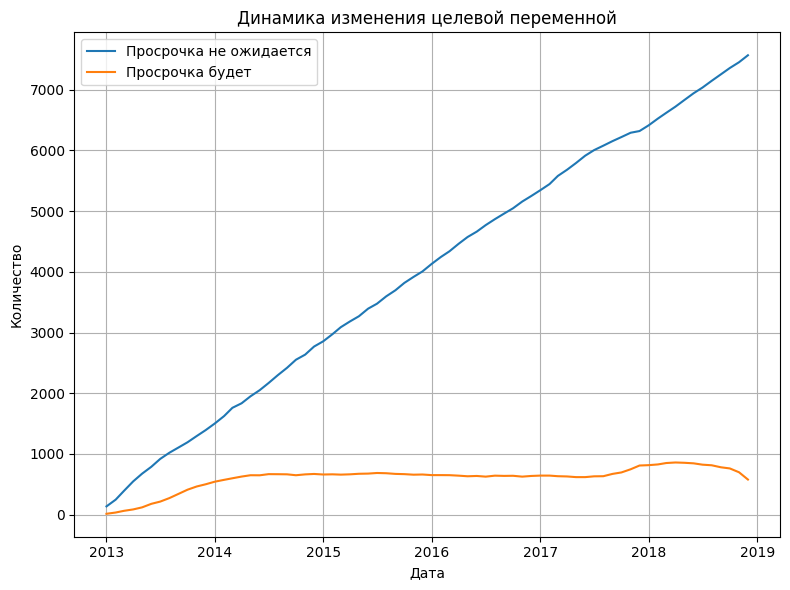

In [10]:
# Подсчет количества значений в классах пл датам
counts = (
    df.groupby(['date', 'default_awaited'])
      .size()
      .unstack(fill_value=0)
)

counts.columns = ['count_0', 'count_1']
plt.figure(figsize=(8, 6))
plt.plot(counts.index, counts['count_0'], label='Просрочка не ожидается')
plt.plot(counts.index, counts['count_1'], label='Просрочка будет')

plt.xlabel('Дата')
plt.ylabel('Количество')
plt.title('Динамика изменения целевой переменной')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

- Классы несбалансированы, дисбаланс увеличивается со временем из-за того, что количество кредитов растет линейно, а количество просрочек сначала медленно растёт, а затем остается примерно на одном уровне. Вероятно, это связано с тем, что датасет содержит данные о клиентах, которые уже выплатили кредит. В этом случае очень важным может оказаться признак времени, прошедшего с регистрации клиента.

### 2.1. Исследование распределения дискретных признаков
- Построим диаграммы распределения дискретных признаков и целевой переменной.

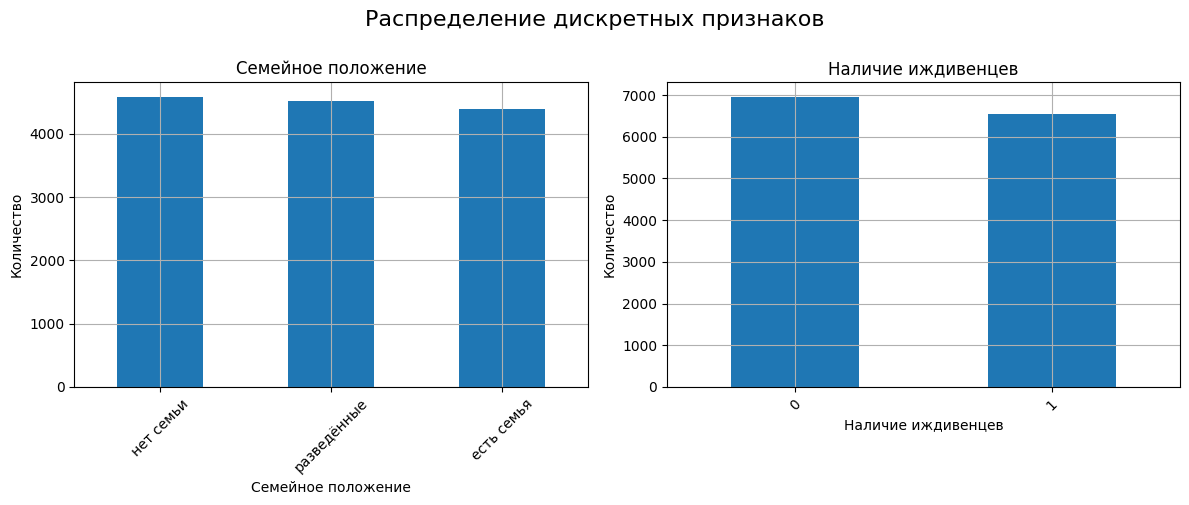

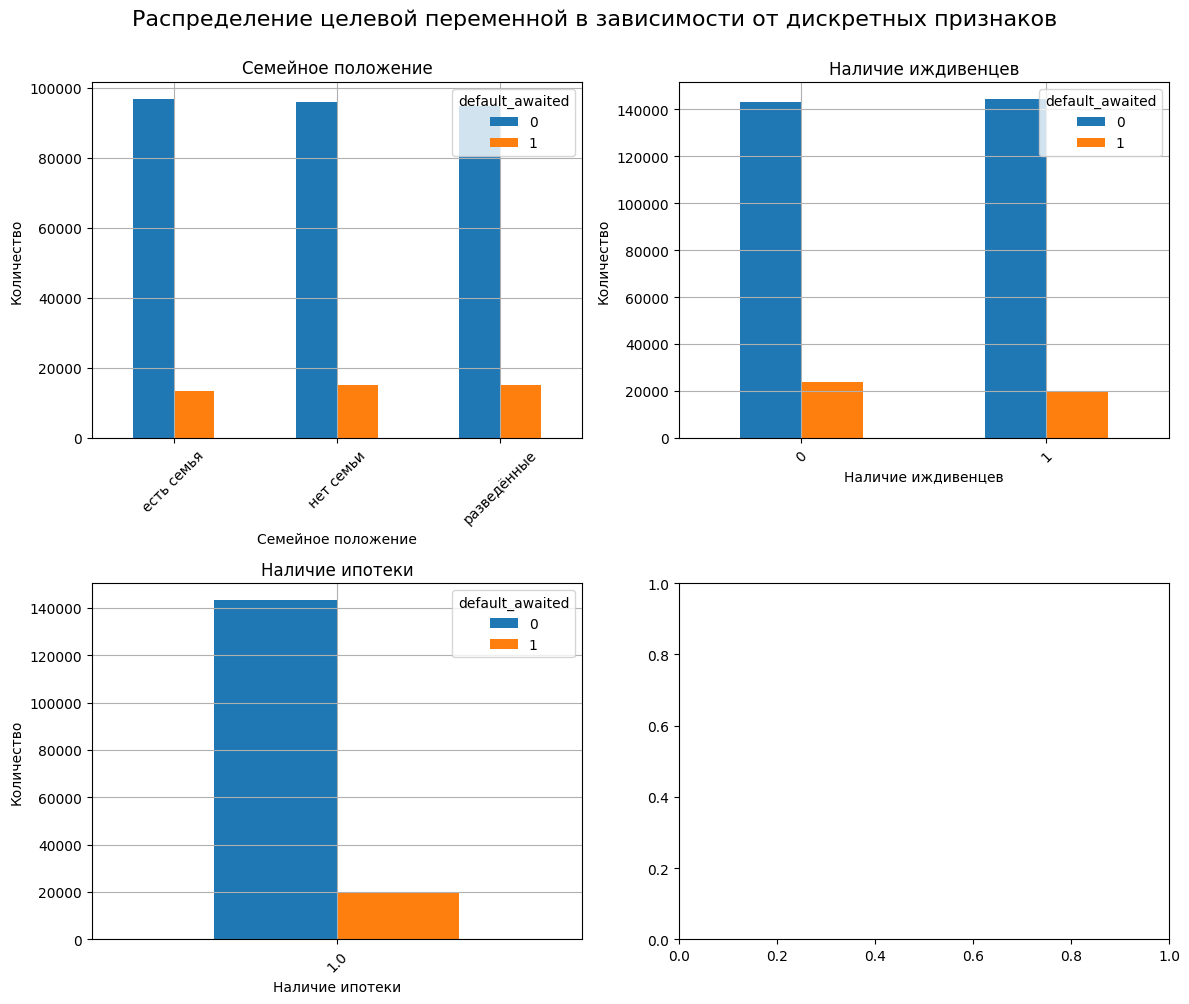

In [11]:
barplot_desc = [
    {"data": datasets['client_description']['семейное_положение'].value_counts(),
     "title": "Семейное положение", "xlabel": "Семейное положение", "ylabel": "Количество", "rot": 45},
    {"data": datasets['client_description']['наличие_иждивенцев'].value_counts(),
     "title": "Наличие иждивенцев", "xlabel": "Наличие иждивенцев", "ylabel": "Количество", "rot": 45}
]

barplot_desc2 = [
    {"data": df.groupby('семейное_положение')[target].value_counts().unstack(fill_value=0),
     "title": "Семейное положение", "xlabel": "Семейное положение", "ylabel": "Количество", "rot": 45},
    {"data": df.groupby('наличие_иждивенцев')[target].value_counts().unstack(fill_value=0),
     "title": "Наличие иждивенцев", "xlabel": "Наличие иждивенцев", "ylabel": "Количество", "rot": 45},
    {"data": df.groupby('наличие_ипотеки')[target].value_counts().unstack(fill_value=0),
     "title": "Наличие ипотеки", "xlabel": "Наличие ипотеки", "ylabel": "Количество", "rot": 45},
]

show_barplot_grid(barplot_desc, "Распределение дискретных признаков")
show_barplot_grid(barplot_desc2, "Распределение целевой переменной в зависимости от дискретных признаков")


- Распределение дискретных признаков близко к равномерному
- Наличие иждивенцев, семьи и ипотеки снижает риск просрочки.

### 2.2. Исследование распределения числовых признаков
- Построим диаграммы распределения числовых признаков клиента по отдельности:

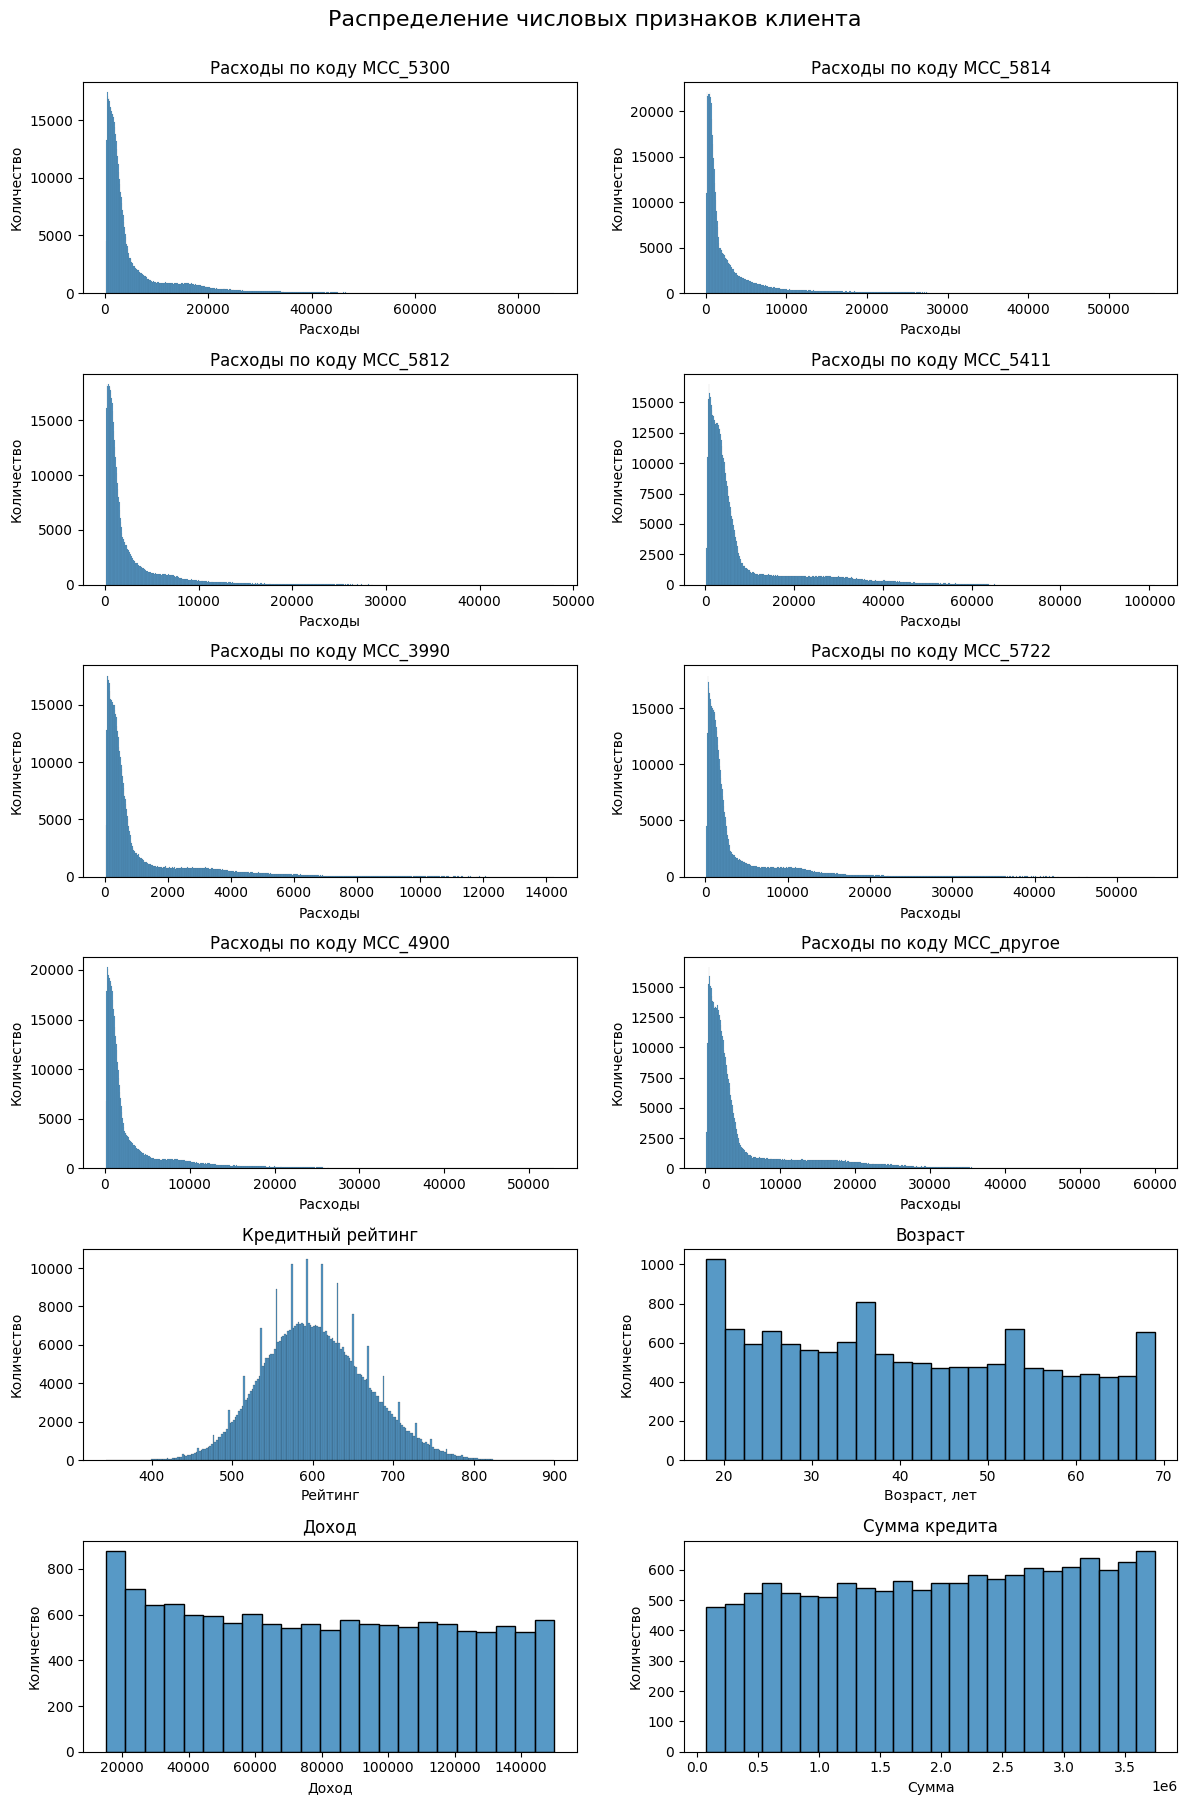

In [12]:
num_features_desc = {
    'MCC_5300': {'data': datasets['transactions'], 'title': "Расходы по коду MCC_5300", 'xlabel': "Расходы"},
    'MCC_5814': {'data': datasets['transactions'], 'title': "Расходы по коду MCC_5814", 'xlabel': "Расходы"},
    'MCC_5812': {'data': datasets['transactions'], 'title': "Расходы по коду MCC_5812", 'xlabel': "Расходы"},
    'MCC_5411': {'data': datasets['transactions'], 'title': "Расходы по коду MCC_5411", 'xlabel': "Расходы"},
    'MCC_3990': {'data': datasets['transactions'], 'title': "Расходы по коду MCC_3990", 'xlabel': "Расходы"},
    'MCC_5722': {'data': datasets['transactions'], 'title': "Расходы по коду MCC_5722", 'xlabel': "Расходы"},
    'MCC_4900': {'data': datasets['transactions'], 'title': "Расходы по коду MCC_4900", 'xlabel': "Расходы"},
    'MCC_другое': {'data': datasets['transactions'], 'title': "Расходы по коду MCC_другое", 'xlabel': "Расходы"},
    'кредитный_рейтинг': {'data': datasets['credit_rating'], 'title': "Кредитный рейтинг", 'xlabel': "Рейтинг"},
    'возраст': {'data': datasets['client_description'], 'title': "Возраст", 'xlabel': "Возраст, лет"},
    'доход': {'data': datasets['credit_description'], 'title': "Доход", 'xlabel': "Доход"},
    'сумма_кредита': {'data': datasets['credit_description'], 'title': "Сумма кредита", 'xlabel': "Сумма"}
}

show_histogram_grid(num_features_desc, "Распределение числовых признаков клиента")

- Также построим диаграммы распределения признаков в совокупности с целевой переменной:

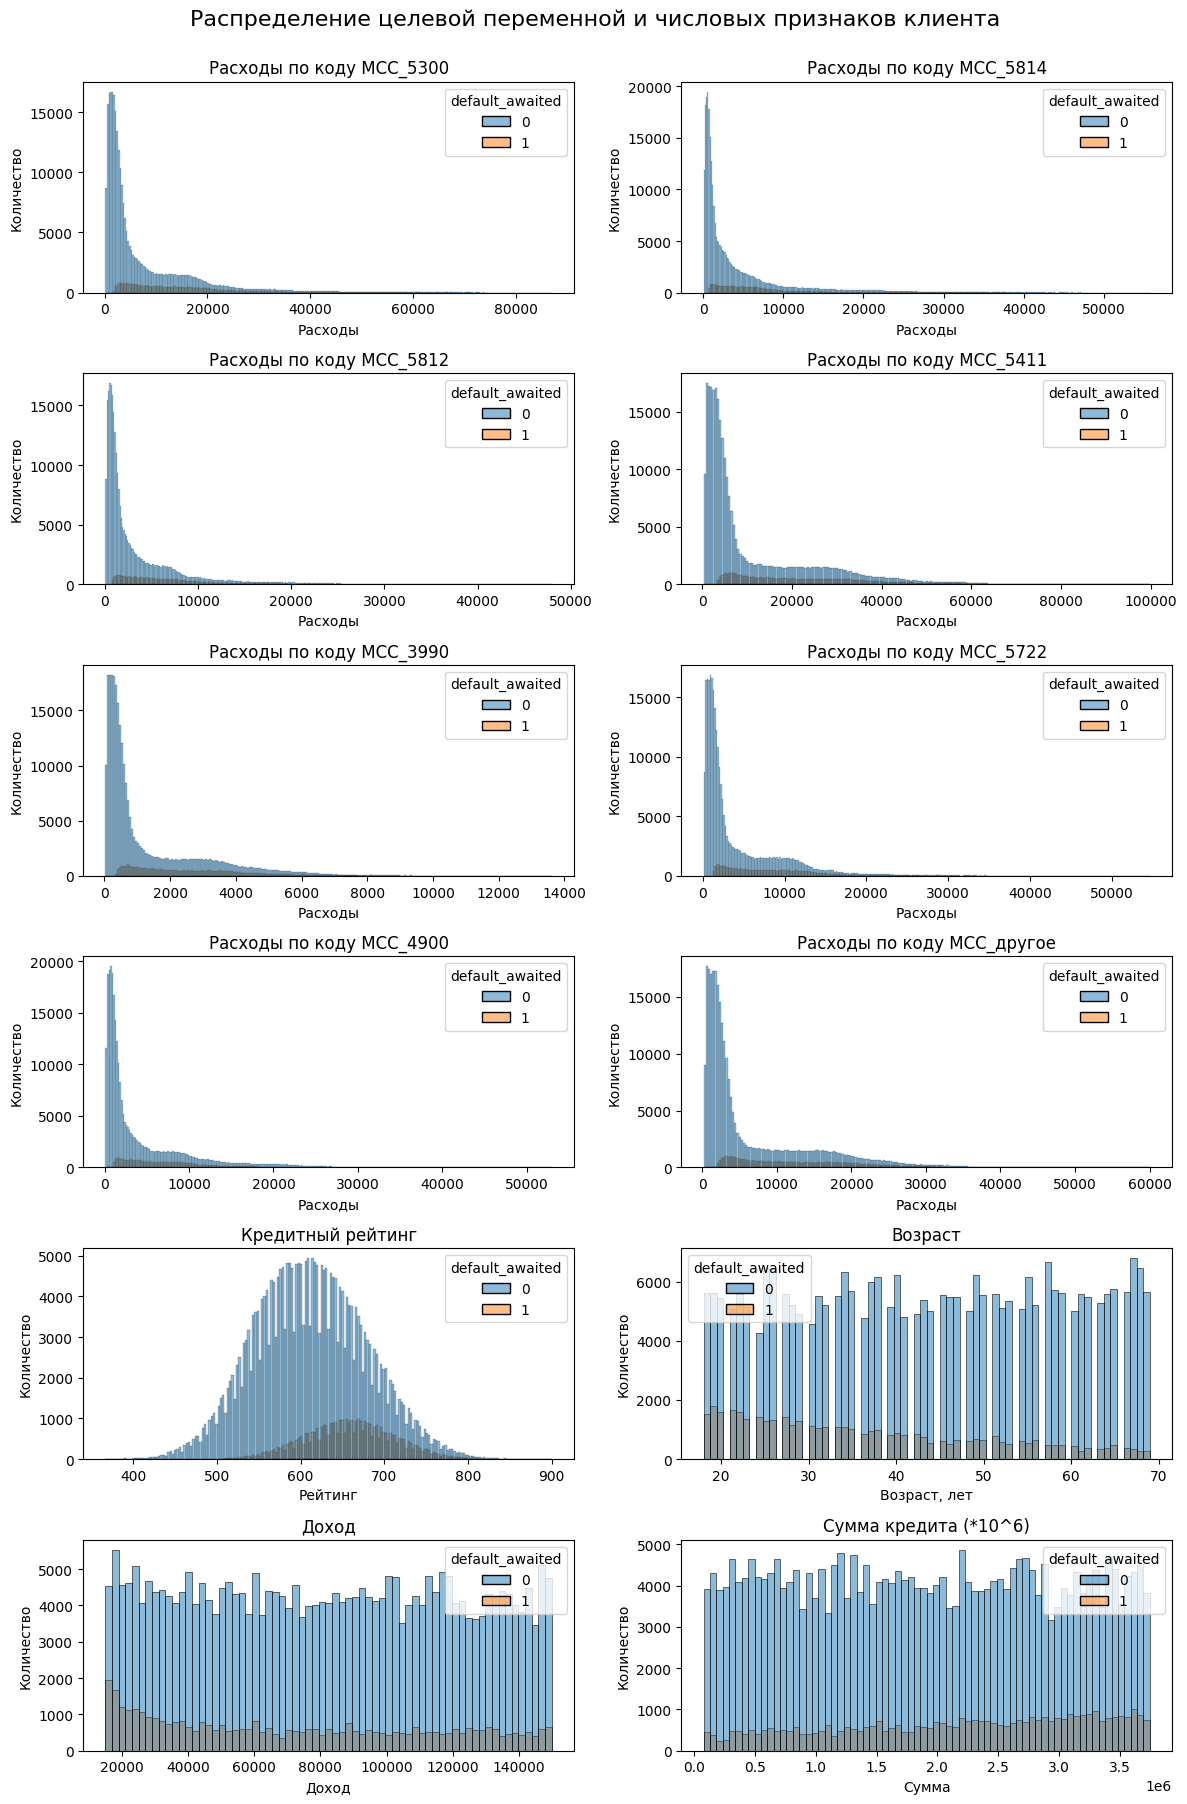

In [13]:
num_features_desc2 = {
    'MCC_5300': {'data': df, 'title': "Расходы по коду MCC_5300", 'xlabel': "Расходы"},
    'MCC_5814': {'data': df, 'title': "Расходы по коду MCC_5814", 'xlabel': "Расходы"},
    'MCC_5812': {'data': df, 'title': "Расходы по коду MCC_5812", 'xlabel': "Расходы"},
    'MCC_5411': {'data': df, 'title': "Расходы по коду MCC_5411", 'xlabel': "Расходы"},
    'MCC_3990': {'data': df, 'title': "Расходы по коду MCC_3990", 'xlabel': "Расходы"},
    'MCC_5722': {'data': df, 'title': "Расходы по коду MCC_5722", 'xlabel': "Расходы"},
    'MCC_4900': {'data': df, 'title': "Расходы по коду MCC_4900", 'xlabel': "Расходы"},
    'MCC_другое': {'data': df, 'title': "Расходы по коду MCC_другое", 'xlabel': "Расходы"},
    'кредитный_рейтинг': {'data': df, 'title': "Кредитный рейтинг", 'xlabel': "Рейтинг"},
    'возраст': {'data': df, 'title': "Возраст", 'xlabel': "Возраст, лет"},
    'доход': {'data': df, 'title': "Доход", 'xlabel': "Доход"},
    'сумма_кредита': {'data': df, 'title': "Сумма кредита (*10^6)", 'xlabel': "Сумма"}
}

show_histogram_grid(num_features_desc2, "Распределение целевой переменной и числовых признаков клиента", hue='default_awaited')

- Расходы по кодам имеют сильно скошенное вправо распределение, пик во всех случаях приходится на суммы менее 1000р. Для модели логистической регрессии эти признаки необходимо прологарифмировать.
- Распределения расходов показывают наличие выбросов, однако суммы 80000-100000р. вполне реальны и не являются следствием ошибки, поэтому удалять их нельзя.
- Распределение кредитного рейтинга нормальное симметричное. Пик просрочек наблюдается для клиентов с кредитным рейтингом выше среднего. 
- Распределение возраста равномерное, с увеличением возраста клиентов риск просрочек уменьшается.
- Распределение дохода близко к равномерному, риск просрочки повышается у клиентов с доходом < 30000р. и увеличивается с уменьшением дохода.
- Распределение суммы кредита также близко к равномерному. С ростом суммы кредита растет риск просрочки.

### 2.3. Исследование корреляции признаков и целевой переменной
- Построим тепловую карту корреляции признаков, используя `phik`:

c:\Users\TEXNH MAKPH\Projects\Yandex DS\ds-yandex\.venv\Lib\site-packages\phik\data_quality.py:82: UserWarning: Not enough unique value for variable наличие_ипотеки for analysis 1. Dropping this column
  warnings.warn(


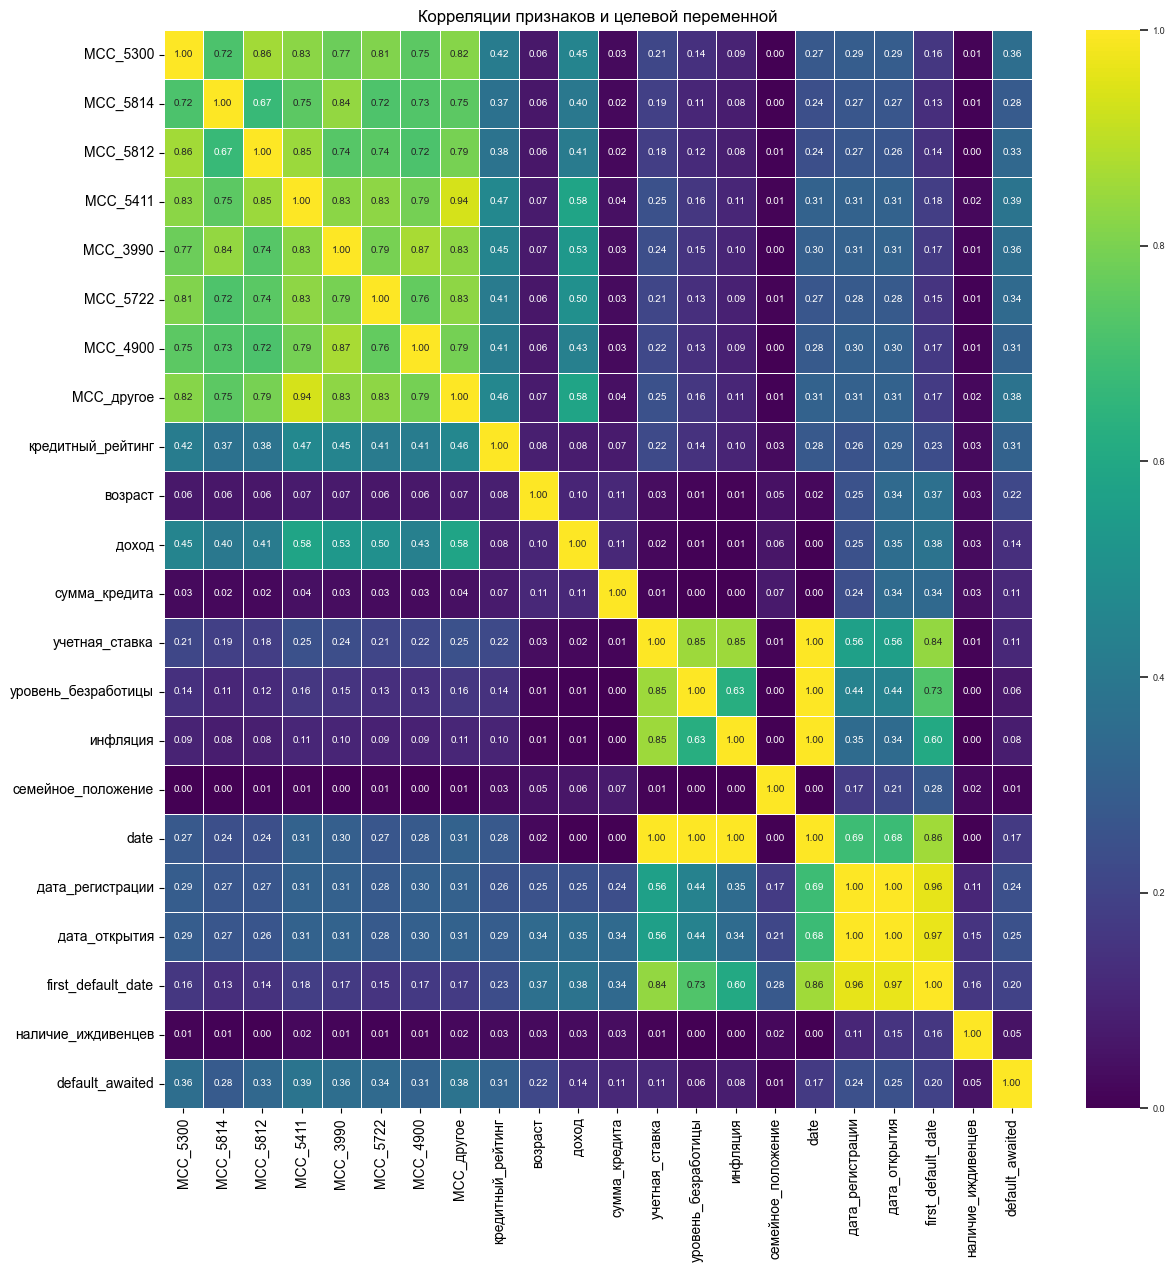

In [14]:
phik_matrix = phik.phik_matrix(df[num_features + cat_features + date_features + bool_features + [target]], 
                               interval_cols=num_features)

draw_heatmap(phik_matrix, "Корреляции признаков и целевой переменной")

- Ожидаемо высока корреляция разных видов расходов друг с другом и с доходами.
- Также ожидаемо высока корреляция временных признаков друг с другом.
- Высокий коэффициент корреляции у макроэкономических признаков - инфляция коррелирует с уровнем безработицы и с учётной ставкой.
- Целевая переменная в наибольшей степени коррелирует с уровнем расходов, возрастом и датой открытия ипотеки.

### 2.4. Выводы
- Классы несбалансированы, дисбаланс увеличивается со временем из-за того, что количество кредитов растет линейно, а количество просрочек сначала медленно растёт, а затем остается примерно на одном уровне.
- Распределение дискретных признаков близко к равномерному
- Наличие иждивенцев, семьи и ипотеки снижает риск просрочки.
- Расходы по кодам имеют сильно скошенное вправо распределение, пик во всех случаях приходится на суммы менее 1000р. Для модели логистической регрессии эти признаки необходимо прологарифмировать.
- Распределения расходов показывают наличие выбросов, однако суммы 80000-100000р. вполне реальны и не являются следствием ошибки, поэтому удалять их нельзя.
- Распределение кредитного рейтинга нормальное симметричное. Пик просрочек наблюдается для клиентов с кредитным рейтингом выше среднего. 
- Распределение возраста равномерное, с увеличением возраста клиентов риск просрочек уменьшается.
- Распределение дохода близко к равномерному, риск просрочки повышается у клиентов с доходом < 30000р. и увеличивается с уменьшением дохода.
- Распределение суммы кредита также близко к равномерному. С ростом суммы кредита растет риск просрочки.
- Высока корреляция разных видов расходов друг с другом и с доходами.
- Высокий коэффициент корреляции у макроэкономических признаков - инфляция коррелирует с уровнем безработицы и с учётной ставкой.
- Целевая переменная в наибольшей степени коррелирует с уровнем расходов, возрастом и датой открытия ипотеки.

## 3. Предобработка данных и создание новых признаков
- Необходимо заполнить пропуски в столбцах, относящихся к ипотеке (в случае отсутствия ипотеки).
- Семейное положение закодируем с использованием One-hot encoding.
- Добавим новые признаки: 
    - средний суммарный ежемесячный расход.
    - отношение среднего месячного расхода к доходу.
    - отношение суммы кредита к доходу.
    - количество дней с регистрации.
- Временные признаки, кроме `date` необходимо удалить.
- Для логистической регрессии числовые признаки необходимо масштабировать.

### 3.1. Пайплайны предобработки
- Создадим пайплайны предобработки для заполнения пропусков, добавления новых и модификации существующих признаков:

In [15]:
def feature_engineering(df):
    df = df.copy()
    outcome_codes = [col for col in df.columns if col.startswith('MCC_')]

    # Средний месячный расход по определенным кодам MCC
    df['средний_месячный_расход'] = (df[outcome_codes]
                                    .sum(axis=1)
                                    .expanding()
                                    .mean()
                                    .shift(-1)
                                    .fillna(0))

    # Логарифмирование расходов для уменьшения влияния выбросов
    df[outcome_codes] = df[outcome_codes].apply(lambda x: np.log1p(x))
    
    # Отношение среднего месячного расхода к доходу
    df['расход_к_доходу'] = df['средний_месячный_расход'] / (df['доход'] + 1e-6)

    # Отношение суммы кредита к доходу
    df['кредит_к_доходу'] = df['сумма_кредита'] / (df['доход'] + 1e-6)

    # Количество дней с момента регистрации
    df['дни_с_регистрации'] = ((df['date'] - df['дата_регистрации'].fillna(df['date'])) / 
                           np.timedelta64(1, 'D')).astype(int)
    
    df.drop(columns=['дата_регистрации', 
                     'дата_открытия', 
                     'first_default_date',
                     'ID',
                     'date'], inplace=True)
    return df

num_features_pp = num_features #[line for line in num_features if not line.startswith("MCC")]

lr_preprocess = ImbPipeline(steps=[
    ('feature_engineering', FunctionTransformer(feature_engineering)),
    ('transformer', ColumnTransformer(transformers=[
        ('fillna', SimpleImputer(strategy='constant', fill_value=0), bool_features),
        ('num', StandardScaler(), num_features_pp),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ], remainder='passthrough'))
])
lr_preprocess.set_output(transform='pandas')

rf_preprocess = ImbPipeline(steps=[
    ('feature_engineering', FunctionTransformer(feature_engineering)),
    ('transformer', ColumnTransformer(transformers=[
        ('fillna', SimpleImputer(strategy='constant', fill_value=0), bool_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ], remainder='passthrough'))
])
rf_preprocess.set_output(transform='pandas')

,steps,"[('feature_engineering', ...), ('transformer', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function fea...001948D5AAAE0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... versionadded:: 0.18",None


### 3.2 Исследование добавленных признаков
- Построим диаграммы распределения добавленных признаков:

<class 'pandas.DataFrame'>
Index: 331228 entries, 0 to 424878
Data columns (total 25 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   fillna__наличие_иждивенцев           331228 non-null  float64
 1   fillna__наличие_ипотеки              331228 non-null  float64
 2   cat__семейное_положение_есть семья   331228 non-null  float64
 3   cat__семейное_положение_нет семьи    331228 non-null  float64
 4   cat__семейное_положение_разведённые  331228 non-null  float64
 5   remainder__MCC_5300                  331228 non-null  float64
 6   remainder__MCC_5814                  331228 non-null  float64
 7   remainder__MCC_5812                  331228 non-null  float64
 8   remainder__MCC_5411                  331228 non-null  float64
 9   remainder__MCC_3990                  331228 non-null  float64
 10  remainder__MCC_5722                  331228 non-null  float64
 11  remainder__MCC_4900          

None

,fillna__наличие_иждивенцев,fillna__наличие_ипотеки,cat__семейное_положение_есть семья,cat__семейное_положение_нет семьи,cat__семейное_положение_разведённые,remainder__MCC_5300,remainder__MCC_5814,remainder__MCC_5812,remainder__MCC_5411,remainder__MCC_3990,...,remainder__доход,remainder__сумма_кредита,remainder__учетная_ставка,remainder__уровень_безработицы,remainder__инфляция,remainder__default_awaited,remainder__средний_месячный_расход,remainder__расход_к_доходу,remainder__кредит_к_доходу,remainder__дни_с_регистрации
0,1.0000,0.0000,0.0000,0.0000,1.0000,8.0921,7.1570,7.2855,8.6503,6.4746,...,27035,1960785,5.5000,5.4000,0.6600,0,23213.2550,0.8586,72.5276,0
1,1.0000,0.0000,0.0000,0.0000,1.0000,8.0701,7.8015,7.1968,8.6700,6.9741,...,27035,1960785,5.5000,5.3000,0.4200,0,23748.2767,0.8784,72.5276,31
2,1.0000,0.0000,0.0000,0.0000,1.0000,8.1751,8.3614,7.2894,8.5584,7.0639,...,27035,1960785,5.5000,5.3000,0.8200,0,23742.8475,0.8782,72.5276,61
3,1.0000,0.0000,0.0000,0.0000,1.0000,8.1277,8.4188,7.1408,8.6599,6.8957,...,27035,1960785,5.5000,5.2000,0.1400,0,23607.9860,0.8732,72.5276,92
4,1.0000,0.0000,0.0000,0.0000,1.0000,8.0758,8.3303,7.2486,8.6364,6.4642,...,27035,1960785,5.5000,5.1000,0.2100,0,23991.6650,0.8874,72.5276,123


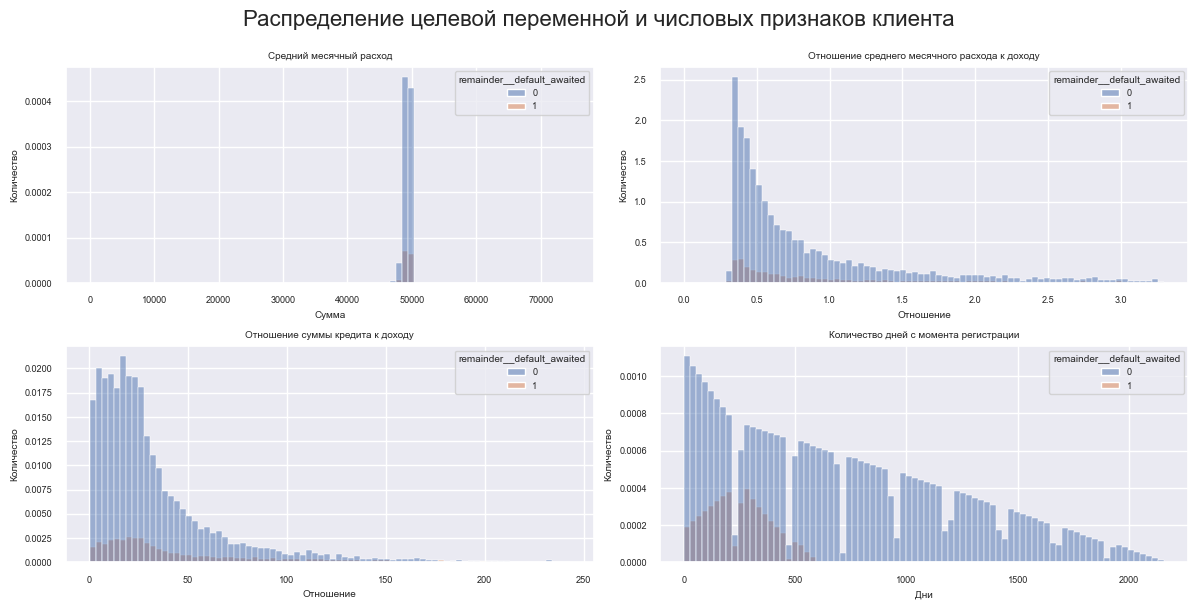

In [16]:
df_pp = rf_preprocess.fit_transform(df)
display(df_pp.info())
display(df_pp.head())
pp_features_desc = {
    'remainder__средний_месячный_расход': {'data': df_pp, 'title': "Средний месячный расход", 'xlabel': "Сумма"},
    'remainder__расход_к_доходу': {'data': df_pp, 'title': "Отношение среднего месячного расхода к доходу", 'xlabel': "Отношение"},
    'remainder__кредит_к_доходу': {'data': df_pp, 'title': "Отношение суммы кредита к доходу", 'xlabel': "Отношение"},
    'remainder__дни_с_регистрации': {'data': df_pp, 'title': "Количество дней с момента регистрации", 'xlabel': "Дни"}
}

show_histogram_grid(pp_features_desc, 
                    "Распределение целевой переменной и числовых признаков клиента", 
                    hue='remainder__default_awaited',
                    stat='density',
                    bins=80)

- Для среднего месячного дохода есть выраженный пик около 50000 р.
- Распределения остальных добавленных признаков правосторонние. Видно, что пик ожидаемых просрочек приходится на 250 дней со дня регистрации, затем к 600 дням их количество падает практически до нуля. Это подтверждает гипотезу о том, что датасеты содержат сведения о клиентах, уже выплативших кредит.

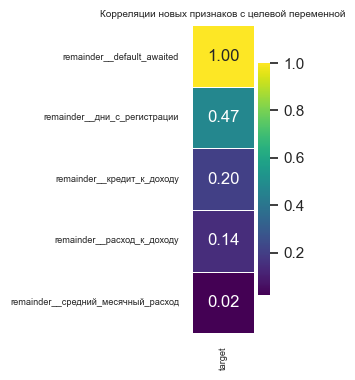

In [17]:
corr_cols = ['remainder__средний_месячный_расход',
            'remainder__расход_к_доходу', 
            'remainder__кредит_к_доходу',
            'remainder__дни_с_регистрации',
            'remainder__default_awaited']

phik_pp = (pd.DataFrame((phik.phik_matrix(df_pp[corr_cols], 
                                        interval_cols=corr_cols)['remainder__default_awaited']
                                        .sort_values(ascending=False)))
            .rename(columns={'remainder__default_awaited': 'target'}))
            
draw_heatmap(phik_pp, "Корреляции новых признаков с целевой переменной", figsize=(1, 4), font_scale=1)

- Корреляция целевой переменной с новым признаком количества дней, прошедших с регистрации, - наибольшая из всех признаков, включая исходные.
- Признаки отношения суммы кредита и расхода к доходу также коррелируют с целевой переменной больше исходных.

### 3.3. Разделение датасета на выборки
- Разделим датасет на обучающую, калибровочную и тестовую выборки. Для калибровочной и тестовой выборок возьмем последние два года наблюдений:

In [18]:
ind_train = (df['date'].dt.year <= 2016)
ind_cal = (df['date'].dt.year == 2017)
ind_test = (df['date'].dt.year == 2018)

# Сортируем строки по дате
df_sorted = df.sort_values(by='date')

# Группы для кросс-валидации
groups = df_sorted[ind_train]['date'].dt.year

X = df_sorted.drop(columns=[target])
y = df_sorted[target]

# Обучающая выборка
X_train, y_train = X[ind_train], y[ind_train]

# Калибрационная выборка
X_cal, y_cal = X[ind_cal], y[ind_cal]

# Тестовая выборка
X_test, y_test = X[ind_test], y[ind_test]


C:\Users\TEXNH MAKPH\AppData\Local\Temp\ipykernel_580\2150116618.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  groups = df_sorted[ind_train]['date'].dt.year
C:\Users\TEXNH MAKPH\AppData\Local\Temp\ipykernel_580\2150116618.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_train, y_train = X[ind_train], y[ind_train]
C:\Users\TEXNH MAKPH\AppData\Local\Temp\ipykernel_580\2150116618.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_cal, y_cal = X[ind_cal], y[ind_cal]
C:\Users\TEXNH MAKPH\AppData\Local\Temp\ipykernel_580\2150116618.py:21: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_test, y_test = X[ind_test], y[ind_test]


### Выводы
- Были созданы пайплайны предобработки данных, добавлены новые признаки: 
    - средний суммарный ежемесячный расход.
    - отношение среднего месячного расхода к доходу.
    - отношение суммы кредита к доходу.
    - количество дней с регистрации.
- Датасет разделён на обучающую, калибрационную и тестовую выборки по годам. В калибрационную и тестовую выборки вошли данные за два последних года (2017, 2018). Остальные данные оставлены для обучения.

## 4. Обучение базовых моделей
### 4.1. Базовые модели логистической регрессии и случайного леса
- Обучим модели логистической регрессии и случайного леса с параметрами по умолчанию на кросс-валидации из 3 фолдов:

In [19]:
def approval_rate_score(y_test, y_pred):
    return np.mean(y_pred == 0)


def default_rate_score(y_test, y_pred):
    approved = (y_pred == 0)
    approved_count = approved.sum()

    if approved_count == 0:
        return 0.0
    defaults_among_approved = np.sum((y_test == 1) & approved)

    return defaults_among_approved / approved_count

def get_scores(y_test, y_pred):
    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred),
        'default_rate': default_rate_score(y_test, y_pred),
        'missed_defaults': 1 - recall_score(y_test, y_pred),
        'approval_rate': approval_rate_score(y_test, y_pred)
    }

def cross_validate_bs(estimator, X, y, cv, groups, prefix = ''):
    accuracy = []
    f1 = []
    precision = []
    recall = []
    roc_auc = []
    default_rate = []
    missed_defaults = []
    approval_rate = []

    for train_ind, val_ind in cv.split(X, groups=groups):
        X_train_cv, y_train_cv = X.iloc[train_ind], y.iloc[train_ind]
        X_val_cv, y_val_cv = X.iloc[val_ind], y.iloc[val_ind]

        estimator.fit(X_train_cv, y_train_cv)
        y_val_pred = estimator.predict(X_val_cv)
        y_val_pred_proba = estimator.predict_proba(X_val_cv)[:, 1]
        accuracy.append(accuracy_score(y_val_cv, y_val_pred))
        f1.append(f1_score(y_val_cv, y_val_pred))
        precision.append(precision_score(y_val_cv, y_val_pred))
        recall.append(recall_score(y_val_cv, y_val_pred))
        roc_auc.append(roc_auc_score(y_val_cv, y_val_pred_proba))
        default_rate.append(default_rate_score(y_val_cv, y_val_pred))
        missed_defaults.append(1 - recall_score(y_val_cv, y_val_pred))
        approval_rate.append(approval_rate_score(y_val_cv, y_val_pred))

    return pd.DataFrame({
        prefix + 'accuracy': accuracy,
        prefix + 'f1': f1,
        prefix + 'precision': precision,
        prefix + 'recall': recall,
        prefix + 'roc_auc': roc_auc,
        prefix + 'default_rate': default_rate,
        prefix + 'missed_defaults': missed_defaults,
        prefix + 'approval_rate': approval_rate
    })

lr_base_cv_args = {
    'train_size': 1,
    'test_size': 1,
    'n_splits': 3,
    'gap_size': 0, 
    'shift_size': 1,
    'window_type': 'rolling'
}

gtscv = GroupTimeSeriesSplit(**lr_base_cv_args)

lr_base_pipeline = Pipeline([
    ('preprocess', lr_preprocess),
    ('model', LogisticRegression(random_state = RANDOM_SEED, solver='liblinear'))
])
display(HTML("<h2>Оценки базовой модели LogisticRegression</h2>"))
lr_base_scores = cross_validate_bs(lr_base_pipeline, X_train, y_train, gtscv, groups)
display(lr_base_scores)

rf_base_pipeline = Pipeline([
    ('preprocess', lr_preprocess),
    ('model', RandomForestClassifier(random_state=RANDOM_SEED))
])
display(HTML("<h2>Оценки базовой модели RandomForestClassifier</h2"))
rf_base_scores = cross_validate_bs(rf_base_pipeline, X_train, y_train, gtscv, groups)
display(rf_base_scores)

,accuracy,f1,precision,recall,roc_auc,default_rate,missed_defaults,approval_rate
0,0.6133,0.2177,0.2034,0.2341,0.5457,0.2393,0.7659,0.7355
1,0.8293,0.1345,0.3865,0.0814,0.6176,0.1550,0.9186,0.9657
2,0.8766,0.0806,0.3747,0.0452,0.7873,0.1161,0.9548,0.9856


,accuracy,f1,precision,recall,roc_auc,default_rate,missed_defaults,approval_rate
0,0.7948,0.3849,0.6185,0.2794,0.7855,0.1848,0.7206,0.8962
1,0.8557,0.3445,0.6629,0.2328,0.8643,0.1326,0.7672,0.9428
2,0.8940,0.3528,0.6563,0.2413,0.9045,0.0951,0.7587,0.9560


- Модели показывают улучшение оценок с увеличением порядкового номера фолда. Это связано с тем, что в датасете с каждым следующим годом количество записей растёт, и обучение проходит успешнее.
- Модель `RandomForestClassifier` показывает лучшие результаты, чем `LogisticRegression`.

### 4.2. Базовые модели с оверсэмплингом
- Добавим в пайплайны оверсэмплинг:

In [20]:
lr_ovs_pipeline = clone(lr_preprocess)
# lr_ovs_pipeline.steps.append(('ovs', SMOTE(k_neighbors=8, random_state=RANDOM_SEED)))
lr_ovs_pipeline.steps.append(('ovs', RandomOverSampler(random_state=RANDOM_SEED)))
lr_ovs_pipeline.steps.append(('model', LogisticRegression(random_state = RANDOM_SEED, solver='liblinear')))

display(HTML("<h2>Оценки модели LogisticRegression с оверсэмплингом RandomOverSampler</h2>"))
lr_ovs_scores = cross_validate_bs(lr_ovs_pipeline, X_train, y_train, gtscv, groups)
display(lr_ovs_scores)

rf_ovs_pipeline = clone(rf_preprocess)
# rf_ovs_pipeline.steps.append(('ovs', SMOTE(k_neighbors=8, random_state=RANDOM_SEED)))
rf_ovs_pipeline.steps.append(('ovs', RandomOverSampler(random_state=RANDOM_SEED)))
rf_ovs_pipeline.steps.append(('model', RandomForestClassifier(random_state = RANDOM_SEED)))

display(HTML("<h2>Оценки модели RandomForestClassifier с оверсэмплингом RandomOverSampler</h2>"))
rf_ovs_scores = cross_validate_bs(rf_ovs_pipeline, X_train, y_train, gtscv, groups)
display(rf_ovs_scores)

,accuracy,f1,precision,recall,roc_auc,default_rate,missed_defaults,approval_rate
0,0.6719,0.5152,0.3901,0.7585,0.7657,0.1004,0.2415,0.5531
1,0.7469,0.5040,0.3703,0.7890,0.8421,0.0527,0.2110,0.6527
2,0.7405,0.4630,0.3078,0.9339,0.8840,0.0124,0.0661,0.6365


,accuracy,f1,precision,recall,roc_auc,default_rate,missed_defaults,approval_rate
0,0.7908,0.3670,0.6027,0.2638,0.7999,0.1881,0.7362,0.8994
1,0.8545,0.2895,0.7092,0.1819,0.8675,0.1391,0.8181,0.9582
2,0.8938,0.2656,0.7757,0.1602,0.9111,0.1032,0.8398,0.9753


### 4.3. Выводы
- Построим общую таблицу метрик всех четырёх моделей со средними значениями по фолдам:

In [21]:
base_scores = pd.DataFrame({
    'LR': lr_base_scores.mean(),
    'LR OVS': lr_ovs_scores.mean(),
    'RF': rf_base_scores.mean(),
    'RF OVS': rf_ovs_scores.mean()
}).T

display(base_scores.style.background_gradient(cmap='viridis', axis=0))

,accuracy,f1,precision,recall,roc_auc,default_rate,missed_defaults,approval_rate
LR,0.773043,0.144258,0.321565,0.120213,0.650206,0.170141,0.879787,0.895594
LR OVS,0.719775,0.494071,0.356053,0.827121,0.830592,0.055163,0.172879,0.614119
RF,0.848137,0.360775,0.645893,0.251155,0.851450,0.137505,0.748845,0.931632
RF OVS,0.846394,0.307346,0.695865,0.201961,0.859515,0.143479,0.798039,0.944286


- Модель `RandomForestClassifier` сильно переобучается - количество пропущенных дефолтов растет от фолда к фолду, а метрика F1 - падает.
- Оверсэмплинг позволяет улучшить метрики, наиболее близкой к целевым показателям стала модель `LogisticClassifier` с оверсэмплингом.
- Тем не менее, ни она из моделей не удовлетворяет требованиям задания по метрике Missed Defaults.

## 5. Подбор гиперпараметров модели `RandomForestClassifier`

### 5.1. Подбор гиперпараметров для `RandomForestClassifier`

In [22]:
def objective_lr(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_samples': trial.suggest_float('max_samples', 0.5, 0.9)
        # 'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])
    }

    rf_pipeline = clone(rf_preprocess)
    # rf_pipeline.steps.append(('ovs', SMOTE(k_neighbors=8, random_state=RANDOM_SEED)))
    # rf_pipeline.steps.append(('us', RandomUnderSampler(sampling_strategy=0.5, random_state=RANDOM_SEED)))
    rf_pipeline.steps.append(('ovs', RandomOverSampler(random_state=RANDOM_SEED)))
    rf_pipeline.steps.append(('model', RandomForestClassifier(random_state=RANDOM_SEED, **params)))

    scores = cross_validate_bs(rf_pipeline, X_train, y_train, gtscv, groups)

    md_score_mean = scores['missed_defaults'].mean()
    trial.report(md_score_mean, step=0)
    if trial.should_prune():
        raise optuna.TrialPruned()

    return md_score_mean

sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)

rf_tree = optuna.create_study(direction="minimize", sampler=sampler) 
rf_tree.optimize(objective_lr, n_trials=15, show_progress_bar=True) 

display(HTML("<h2>Лучшие гиперпараметры:</h2>"))
display(pd.Series(rf_tree.best_params))
display(HTML(f"<h2>Лучшее значение Missed Defaults: </h2>{rf_tree.best_value:8f}"))

[I 2026-06-08 00:16:07,199] A new study created in memory with name: no-name-44d5b7e5-525c-4de9-ae3d-d19b759b299c
Best trial: 0. Best value: 0.312415:   7%|▋         | 1/15 [00:33<07:53, 33.81s/it]

[I 2026-06-08 00:16:41,014] Trial 0 finished with value: 0.31241473238811124 and parameters: {'n_estimators': 175, 'max_depth': 15, 'min_samples_leaf': 16, 'min_samples_split': 13, 'max_samples': 0.5624074561769746}. Best is trial 0 with value: 0.31241473238811124.


Best trial: 1. Best value: 0.18113:  13%|█▎        | 2/15 [00:49<05:04, 23.41s/it] 

[I 2026-06-08 00:16:57,139] Trial 1 finished with value: 0.1811300297826398 and parameters: {'n_estimators': 131, 'max_depth': 5, 'min_samples_leaf': 18, 'min_samples_split': 13, 'max_samples': 0.7832290311184182}. Best is trial 1 with value: 0.1811300297826398.


Best trial: 1. Best value: 0.18113:  20%|██        | 3/15 [01:10<04:22, 21.91s/it]

[I 2026-06-08 00:17:17,277] Trial 2 finished with value: 0.30777684145102857 and parameters: {'n_estimators': 104, 'max_depth': 15, 'min_samples_leaf': 18, 'min_samples_split': 6, 'max_samples': 0.5727299868828403}. Best is trial 1 with value: 0.1811300297826398.


Best trial: 1. Best value: 0.18113:  27%|██▋       | 4/15 [01:24<03:27, 18.90s/it]

[I 2026-06-08 00:17:31,555] Trial 3 finished with value: 0.22484014898776725 and parameters: {'n_estimators': 136, 'max_depth': 8, 'min_samples_leaf': 13, 'min_samples_split': 10, 'max_samples': 0.6164916560792167}. Best is trial 1 with value: 0.1811300297826398.


Best trial: 1. Best value: 0.18113:  33%|███▎      | 5/15 [01:55<03:51, 23.19s/it]

[I 2026-06-08 00:18:02,362] Trial 4 finished with value: 0.19292578761051224 and parameters: {'n_estimators': 222, 'max_depth': 6, 'min_samples_leaf': 9, 'min_samples_split': 8, 'max_samples': 0.6824279936868144}. Best is trial 1 with value: 0.1811300297826398.


Best trial: 1. Best value: 0.18113:  40%|████      | 6/15 [02:29<04:01, 26.84s/it]

[I 2026-06-08 00:18:36,280] Trial 5 finished with value: 0.20869320988564832 and parameters: {'n_estimators': 257, 'max_depth': 7, 'min_samples_leaf': 13, 'min_samples_split': 13, 'max_samples': 0.5185801650879991}. Best is trial 1 with value: 0.1811300297826398.


Best trial: 1. Best value: 0.18113:  47%|████▋     | 7/15 [03:04<03:58, 29.79s/it]

[I 2026-06-08 00:19:12,140] Trial 6 finished with value: 0.1937497518463697 and parameters: {'n_estimators': 222, 'max_depth': 6, 'min_samples_leaf': 6, 'min_samples_split': 20, 'max_samples': 0.8862528132298237}. Best is trial 1 with value: 0.1811300297826398.


Best trial: 1. Best value: 0.18113:  53%|█████▎    | 8/15 [03:47<03:56, 33.73s/it]

[I 2026-06-08 00:19:54,309] Trial 7 pruned. 


Best trial: 1. Best value: 0.18113:  60%|██████    | 9/15 [04:10<03:03, 30.59s/it]

[I 2026-06-08 00:20:18,002] Trial 8 pruned. 


Best trial: 1. Best value: 0.18113:  67%|██████▋   | 10/15 [04:46<02:41, 32.29s/it]

[I 2026-06-08 00:20:54,100] Trial 9 pruned. 


Best trial: 1. Best value: 0.18113:  73%|███████▎  | 11/15 [05:26<02:17, 34.41s/it]

[I 2026-06-08 00:21:33,297] Trial 10 pruned. 


Best trial: 1. Best value: 0.18113:  80%|████████  | 12/15 [05:50<01:34, 31.51s/it]

[I 2026-06-08 00:21:58,189] Trial 11 finished with value: 0.18363014754106785 and parameters: {'n_estimators': 188, 'max_depth': 5, 'min_samples_leaf': 9, 'min_samples_split': 8, 'max_samples': 0.761236336489977}. Best is trial 1 with value: 0.1811300297826398.


Best trial: 12. Best value: 0.179576:  87%|████████▋ | 13/15 [06:13<00:57, 28.67s/it]

[I 2026-06-08 00:22:20,320] Trial 12 finished with value: 0.17957580705206985 and parameters: {'n_estimators': 165, 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 5, 'max_samples': 0.7754456622832818}. Best is trial 12 with value: 0.17957580705206985.


Best trial: 13. Best value: 0.179348:  93%|█████████▎| 14/15 [06:33<00:26, 26.05s/it]

[I 2026-06-08 00:22:40,311] Trial 13 finished with value: 0.1793480173116565 and parameters: {'n_estimators': 148, 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2, 'max_samples': 0.7795531433639472}. Best is trial 13 with value: 0.1793480173116565.


Best trial: 13. Best value: 0.179348: 100%|██████████| 15/15 [07:05<00:00, 28.40s/it]

[I 2026-06-08 00:23:13,128] Trial 14 pruned. 


n_estimators        148.0000
max_depth             5.0000
min_samples_leaf     10.0000
min_samples_split     2.0000
max_samples           0.7796
dtype: float64

- Посчитаем метрики модели с лучшими параметрами на кросс-валидации:

In [23]:
# best_params =  rf_tree.best_params
best_params = {'n_estimators': 131, 'max_depth': 5, 'min_samples_leaf': 18, 'min_samples_split': 13, 'max_samples': 0.7832290311184182}
rf_pipeline = clone(rf_preprocess)
rf_pipeline.steps.append(('ovs', RandomOverSampler(random_state=RANDOM_SEED)))
rf_pipeline.steps.append(('model', RandomForestClassifier(random_state=RANDOM_SEED, **best_params)))

rf_best_scores = cross_validate_bs(rf_pipeline, X_train, y_train, gtscv, groups)
display(rf_best_scores)

,accuracy,f1,precision,recall,roc_auc,default_rate,missed_defaults,approval_rate
0,0.6225,0.4877,0.3544,0.7817,0.7393,0.1018,0.2183,0.4931
1,0.7655,0.4938,0.3809,0.7018,0.8333,0.0694,0.2982,0.6998
2,0.7017,0.4387,0.2832,0.9732,0.8846,0.0055,0.0268,0.5883


### 5.2. Выводы
- Полученная модель имеет уровень одобрения кредитов ниже заданного - она слишком осторожна. На каждом следующем фолде метрика recall увеличивается, а precision - уменьшается.
- Для достижения заданных параметров необходима калибровка и настройка порога вероятности положительного класса.

## 6. Калибровка модели и подбор порога вероятности положительного класса
### 6.1. Калибровка модели
- Построим калибровочную кривую для полученной модели:

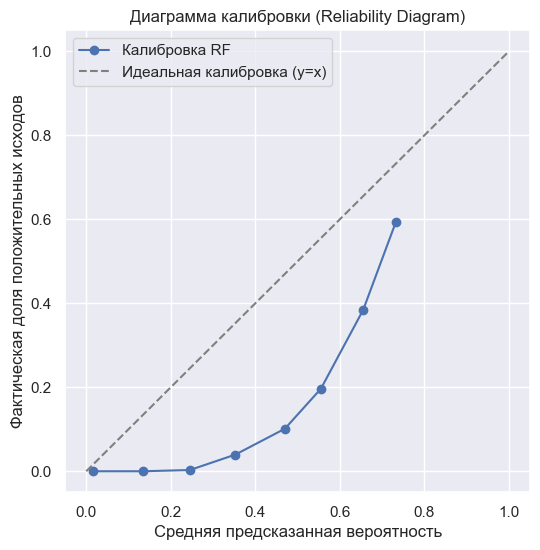

In [24]:
rf_pipeline.fit(X_train, y_train)
y_pred_proba_uncal = rf_pipeline.predict_proba(X_cal)[:, 1]
rf_prob_true, rf_prob_pred = calibration_curve(y_cal, y_pred_proba_uncal, n_bins=10)

# Шаг 3: строим график
def draw_calib_curve(list):
    plt.figure(figsize=(6,6))
    for l in list:
        plt.plot(l[1], l[0], marker='o', label=l[2])

    plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Идеальная калибровка (y=x)')
    plt.xlabel('Средняя предсказанная вероятность')
    plt.ylabel('Фактическая доля положительных исходов')
    plt.title('Диаграмма калибровки (Reliability Diagram)')
    plt.legend()
    plt.grid(True)
    plt.show()

draw_calib_curve([(rf_prob_true, rf_prob_pred, "Калибровка RF")])
rf_brier_uncal = brier_score_loss(y_cal, y_pred_proba_uncal)
display(HTML(f"<h2>Brier score: </h2>{rf_brier_uncal:.4f}"))

- Откалибруем модель с использованием изотонической калибровки на всей калибровочной выборке:

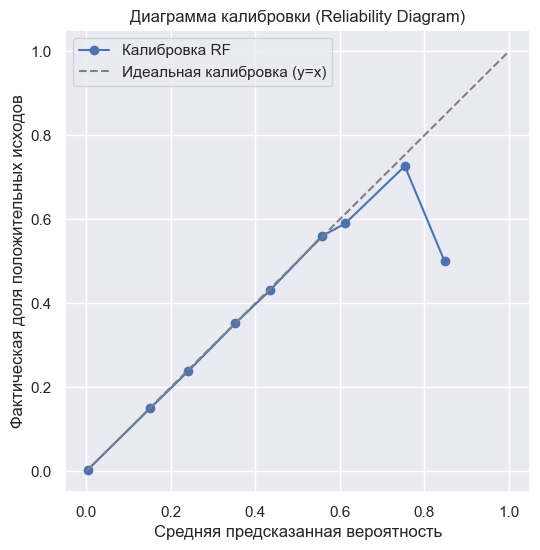

In [25]:
rf_calibrated = CalibratedClassifierCV(
    estimator=FrozenEstimator(rf_pipeline),
    method='isotonic')
rf_calibrated.fit(X_cal, y_cal)

y_pred_proba_cal = rf_calibrated.predict_proba(X_cal)[:, 1]
rf_prob_true_cal, rf_prob_pred_cal = calibration_curve(y_cal, y_pred_proba_cal, n_bins=10)
draw_calib_curve([(rf_prob_true_cal, rf_prob_pred_cal, "Калибровка RF")])
rf_brier_cal = brier_score_loss(y_cal, y_pred_proba_cal)
display(HTML(f"<h2>Brier score: </h2>{rf_brier_cal:.4f}"))

- Калибровка модели улучшилась: кривая стала ближе к идеальной, оценка Бриера уменьшилась до 0.67.

### 6.2. Подбор порога вероятности положительного класса

- Подберём значение вероятности положительного класса, используя данные кривой Precision/Recall. Из подходящих значений порога выберем то, на котором максимальна метрика F1.

In [26]:
# Кривая Precision-Recall для оценки различных порогов классификации
pc_curve = precision_recall_curve(y_cal, y_pred_proba_cal)

missed_defaults = [(1 - recall_score(y_cal, y_pred_proba_cal >= threshold)) for threshold in pc_curve[2]]
default_rates = [default_rate_score(y_cal, y_pred_proba_cal >= threshold) for threshold in pc_curve[2]]
approval_rates = [approval_rate_score(y_cal, y_pred_proba_cal >= threshold) for threshold in pc_curve[2]]
recall_scores = [recall_score(y_cal, y_pred_proba_cal >= threshold) for threshold in pc_curve[2]]
precision_scores = [precision_score(y_cal, y_pred_proba_cal >= threshold) for threshold in pc_curve[2]]
f1_scores = [f1_score(y_cal, y_pred_proba_cal >= threshold) for threshold in pc_curve[2]]
accuracy_scores = [accuracy_score(y_cal, y_pred_proba_cal >= threshold) for threshold in pc_curve[2]]

threshold_scores = pd.DataFrame({
    'Threshold': pc_curve[2],
    'Missed Defaults': missed_defaults,
    'Default Rate': default_rates,
    'Approval Rate': approval_rates,
    'Recall': recall_scores,
    'Precision': precision_scores,
    'F1': f1_scores,
    'Accuracy': accuracy_scores
})

threshold_table = threshold_scores[(threshold_scores['Missed Defaults'] <= 0.04) &
                         (threshold_scores['Approval Rate'] >= 0.65) &
                         (threshold_scores['Default Rate'] <= 0.02)].sort_values(by='F1', ascending=False)

best_threshold = round(threshold_table.iloc[0]['Threshold'], 3)
display(HTML(f"<h2>Значение порога: </h2>{best_threshold}"))

### 6.3. Выводы
- Исходная модель давала слишком пессимистичные предсказания. Калибровка приблизила предсказываемые вероятности к реальному соотношению классов в калибровочной выборке.
- Был подобран порог вероятности, который, при сохранении целевых показателей в пределах заданных, максимизирует метрику F1.

# 7. Тестирование и интерпретация модели
### 7.1. Оценка модели на тестовой выборке

In [27]:
y_pred_cal = y_pred_proba_cal >= best_threshold
y_pred_test = rf_calibrated.predict_proba(X_test)[:, 1] >= best_threshold
final_scores_df = pd.DataFrame({
    'Calibration Score': get_scores(y_cal, y_pred_cal),
    'Test Score': get_scores(y_test, y_pred_test),
})
display(final_scores_df.T.style.background_gradient(cmap='viridis', axis=1))

,accuracy,f1,precision,recall,roc_auc,default_rate,missed_defaults,approval_rate
Calibration Score,0.762951,0.452900,0.295550,0.968554,0.854165,0.004769,0.031446,0.668020
Test Score,0.823495,0.524484,0.361496,0.955123,0.881841,0.006259,0.044877,0.730728


- Метрики на тестовой выборке подтверждают качество модели - целевые показатели соблюдены, по accuracy, F1, precision, Approval Rate модель показывает лучшие результаты, чем на калибровочной.

### 7.2. Оценка матриц ошибок
- Построим матрицы ошибок для калибровочной и тестовой выборок:

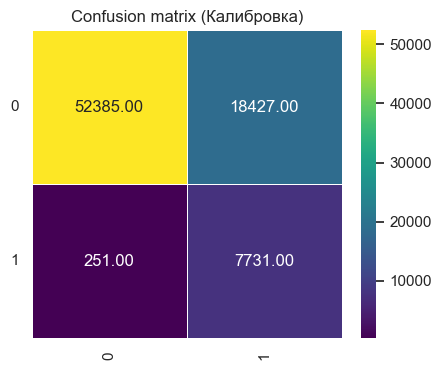

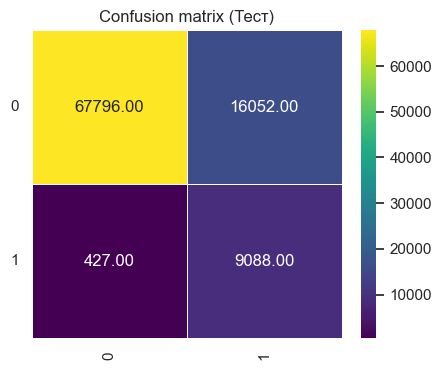

In [28]:
conf_matrix_cal = confusion_matrix(y_cal, y_pred_cal)
draw_heatmap(conf_matrix_cal,
             "Confusion matrix (Калибровка)",
             figsize=(5, 4),
             font_scale=1)

conf_matrix_test = confusion_matrix(y_test, y_pred_test)
draw_heatmap(conf_matrix_test,
             "Confusion matrix (Тест)",
             figsize=(5, 4),
             font_scale=1)

### 7.3. Интерпретация модели - оценка значимости признаков
- Отсортируем признаки по значимости (на основании `feature_importances`):

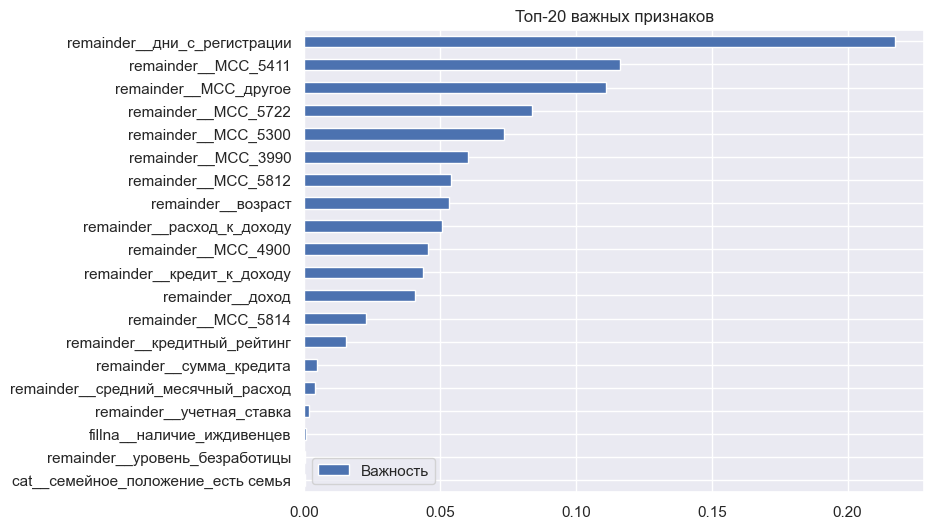

In [29]:
rf_pipeline.named_steps['model'].feature_importances_
feature_names = rf_pipeline.named_steps['transformer'].get_feature_names_out()
feature_importances = pd.DataFrame({'Важность': rf_pipeline.named_steps['model'].feature_importances_}, index=feature_names)
top_features = feature_importances.sort_values('Важность', ascending=True)
top_features.tail(20).plot(kind='barh', figsize=(8, 6), title='Топ-20 важных признаков')
plt.show()

### 7.3. Выводы
- Модель достаточно стабильна и не переучена.
- Полученная модель сответствует предъявленным требованиям по метрикам Approval Rate, Missed Defaults, Default Rate.
- Ошибки модели, в основном, связаны с определением надежных клиентов как рискованных - модель слишком осторожна. Для повышения Approval Rate в ущерб точности выявления дефолтов можно увеличить порог вероятности положительного класса.
- Наиболее важными признаками являются количество дней, поршедших с регистрации, расходы по кодам, возраст, отношения дохода к расходу и суммы кредита к доходу.

## 8. Финальное обучение и сохранение модели
- Обучим модель на объединенной обучающей и калибровочной выборке:

In [30]:
final_pipeline_int = clone(lr_preprocess)
final_pipeline_int.steps.append(('ovs', RandomOverSampler(random_state=RANDOM_SEED)))
final_pipeline_int.steps.append(('model', RandomForestClassifier(random_state=RANDOM_SEED, **best_params)))

X_full = pd.concat([X_train, X_cal])
y_full = pd.concat([y_train, y_cal])
final_pipeline = CalibratedClassifierCV(
    estimator=final_pipeline_int,
    method='isotonic')
final_pipeline.fit(X_full, y_full)
y_final_pred_proba = final_pipeline.predict_proba(X_test)[:, 1]

y_final_pred = y_final_pred_proba >= best_threshold
final_scores_df = pd.DataFrame({
    'Final Test Score': get_scores(y_test, y_final_pred)})
display(final_scores_df.T.style.background_gradient(cmap='viridis', axis=1))

,accuracy,f1,precision,recall,roc_auc,default_rate,missed_defaults,approval_rate
Final Test Score,0.810342,0.517586,0.349356,0.998318,0.893665,0.000242,0.001682,0.708771


- Модель, обученная на расширенной выборке, показывает значительно лучшие результаты и имеет большой запас для увеличения порога Approval Rate без нарушения условий на прочие бизнес-метрики.

- Сохраним пайплайн и проверим корректность сохранения:

In [31]:
PIPELINE_FILE_NAME = "default_prediction.joblib"

try:
    # Сохраним пайплайн
    joblib.dump(final_pipeline, PIPELINE_FILE_NAME)
except Exception as e:
    print("Ошибка сохранения артефактов:", e)
    raise

print("Артефакты сохранены")

# Проверка сохранения и загрузки
try:
    predict_pipeline_loaded = joblib.load(PIPELINE_FILE_NAME)
except Exception as e:
    print("Ошибка загрузки артефактов:", e)
    raise

y_loaded_pred_proba = predict_pipeline_loaded.predict_proba(X_test)[:, 1]
y_loaded_pred = y_loaded_pred_proba >= best_threshold

diff_pred = np.abs(y_final_pred_proba - y_loaded_pred_proba).sum()

if diff_pred == 0.0:
    print("Пайплайн сохранен, проверка прошла успешно.")
else:
    print("Ошибка: ", diff_pred)

Артефакты сохранены
Пайплайн сохранен, проверка прошла успешно.


## 9. Выводы
- Для анализа и разработки подели предсказания были представлены связанные таблицы в формате CSV. Таблицы были загружены и проанализированы на наличие пропусков и выбросов. Пропусков и ошибочных выбросов не найдено.
- Таблицы были объединены в датасет, рассчитано значение целевой переменной.
- В процессе исследовательского анализа данных были исследованы распределения целевой переменной, категориальных и числовых признаков. Оказалось, что дисбаланс классов целевой переменной растёт со временем, поэтому важным признаком является время, прошедшее с регистрации клиента.
- Было выяснено, что целевая переменная в наибольшей степени коррелирует с уровнем расходов, возрастом и датой открытия ипотеки.
- В датасет были добавлены следующие признаки, рассчитанные с учётом временной структуры данных: 
    - средний суммарный ежемесячный расход.
    - отношение среднего месячного расхода к доходу.
    - отношение суммы кредита к доходу.
    - количество дней с регистрации.
- Датасет был разделен на обучающую, калибрационную и тестовую выборки по периодам (2013-2016 года, 2017 год, 2018 год.). Данные с неполным горизонтом планирования за 2019 год были удалены.
- На обучающей выборке были обучены модели логистической регрессии и случайного леса с параметрами по умолчанию. Обе модели были обучены как на несбалансированных данных, так и на данных, подвергнутых простому случайному оверсэмплингу (`RandomOverSampling`).
- Модели с оверсэмплингом показали лучшие результаты, однако их показатели не удовлетворяли требованиям задания. Модель случайного леса показала значительное переобучение.
- Для модели случайного леса был выполнен подбор гиперпараметров с использованием байесовской оптимизации (библиотека Optuna). Был выбран набор гиперпараметров, минимизирующий метрику Missed Defaults.
- Модель с лучшими гиперпараметрами была откалибрована с использованием изотонической калибровки.
- Порог вероятности определения положительного класса был подобран таким образом, чтобы значения метрик удовлетворяли условиям задания, и метрика F1 была максимальной.
- На тестовой выборке модель показала хорошие результаты, удовлетворяющие сформулированным требованиям; по метикам accuracy, F1, precision, Approval Rate модель показала лучшие результаты, чем на калибровочной выборке.
- Модель была обучена на расширенной выборке, составленной из обучающей и калибрационной выборок. На тестировании она показывает значительно лучшие результаты и имеет большой запас для увеличения порога Approval Rate без нарушения условий на прочие бизнес-метрики.
- Наиболее важными признаками являются количество дней, прошедших с регистрации, расходы по кодам, возраст, отношения дохода к расходу и суммы кредита к доходу.
- Обученный пайплайн был сохранен, проверка сохранения прошла успешно.
- Модель настроена таким образом, чтобы уменьшить риски дефолтов, матрица ошибок показывает, что основной объем ошибок - классификация надежных клиентов как рискованных. Для увеличения количества выдаваемых кредитов можно увеличить порог вероятности положительного класса. Запас, который имеет модель, позволяет это сделать без нарушения основных требований к бизнес-метрикам.